### Warp tfMRI to MNI

In [ ]:
import os
import subprocess
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

def warp_to_mni(subject_dir, task):
    """
    Warp a subject's functional data for a given task to MNI space using FSL's applywarp.
    Ensures no existing files are overwritten by appending a timestamp if needed.
    """
    bold_dir     = os.path.join(subject_dir, 'BOLD', task, 'preprocessing')
    anat_reg_dir = os.path.join(subject_dir, 'anatomy', 'preprocessing', 'reg2MNI152')
    proc_dir     = os.path.join(bold_dir, f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')

    input_nii   = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp.nii.gz')
    premat      = os.path.join(bold_dir, 'reg', f'{task}_example_func_ns2highres.mat')
    warp_coeff  = os.path.join(anat_reg_dir, 'highres2reference_warp.nii.gz')
    ref         = os.path.join(anat_reg_dir, 'reference_brain.nii.gz')
    output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')

    # Check inputs
    for f in (input_nii, premat, warp_coeff, ref):
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing file for {task} in {os.path.basename(subject_dir)}: {f}")

    if os.path.exists(output_nii):
        raise FileExistsError(f"{output_nii} already exists - stopping to avoid overwrite")


    cmd = [
        "applywarp",
        "--ref="+ref,
        "--in=" + input_nii,
        "--warp=" + warp_coeff,
        "--premat="+premat,
        "--out="+output_nii
    ]
    subprocess.run(cmd, check=True)
    return os.path.basename(subject_dir), task, output_nii

root = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs = [d for d in os.listdir(root) if d.isdigit()]

results = {}
with ProcessPoolExecutor(max_workers=20) as executor:
    futures = {
        executor.submit(warp_to_mni, os.path.join(root, sub), task): (sub, task)
        for sub in subs for task in tasks
    }
    for future in as_completed(futures):
        sub, task = futures[future]
        try:
            _, _, out = future.result()
            print(f"[{sub} | {task}] → {out}")
            results[(sub, task)] = out
        except Exception as e:
            print(f"[{sub} | {task}] FAILED: {e}")

print("Warping complete for all tasks:", results)


In [ ]:
import os

root  = '/project_cephfs/3022035.06/LEAP_wave1'
tasks = ['REWARD_M', 'REWARD_S']
subs  = [d for d in os.listdir(root) if d.isdigit()]

for task in tasks:
    print(task)
    total = 0
    exists = 0
    for sub in subs:
        subj_dir = os.path.join(root, sub)
        total += 1
        proc_dir    = os.path.join(subj_dir, 'BOLD', task, 'preprocessing',  f'{task}.ica_aroma', 'nr_wm_csf', 'highpassfilter')
        output_nii  = os.path.join(proc_dir, 'denoised_func_data_nonaggr_res_pp2MNI152.nii.gz')
        if os.path.exists(output_nii):
            exists += 1

    print(f"{exists} out of {total} expected output files exist")

### Mask Analysis

In [ ]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from nilearn import datasets
from nilearn.maskers import NiftiMasker

def visualize_masks_on_random_subjects(asd_df, mask_path, output_dir, n_subjects=3):
    os.makedirs(output_dir, exist_ok=True)

    try:
        # Load the group mask
        mask_img = nib.load(mask_path)
        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"  # change if needed

        # Pick random subjects
        random_subjects = asd_df.sample(n=min(n_subjects, len(asd_df)))

        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")

            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            subj_brain_img = nib.load(subject_brain_path)

            # Plot
            plotting.plot_roi(mask_img, bg_img=subj_brain_img,title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            masker = NiftiMasker(mask_img=mask_path, standardize=True, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata()[:,:,:,0],reconstructed_func.affine,reconstructed_func.header)
            plotting.plot_stat_map(one_img,  bg_img=subj_brain_img, threshold=0.0, title=f"First fMRI Volume: Subject {subj_id}",black_bg=False,  dim=0.5)
            plotting.show()


    except Exception as e:
        print(f"Error visualizing mask: {e}")

    print("\nMask visualization complete!")



output_dir   = "/project/3022057.01/LEAP/GroupMasks"      
os.makedirs(output_dir, exist_ok=True)

subjects_csv = "/project/3022057.01/LEAP/final_subjects.csv" 
asd_df = pd.read_csv(subjects_csv)
# Thresh hold for whole brain
threshhold = .95

# Grey matter mask from combining subjects; thresholded at median of avrerage
print("\nBuilding group grey matter mask from subject GM masks...")
all_gm_paths = asd_df['mask_path'].tolist()
sample_img = nib.load(all_gm_paths[0])
gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
gm_mean = np.mean(gm_data, axis=0)
# gm_mask = (gm_mean >= 0.2).astype(np.uint8)
median_val = np.median(gm_mean[gm_mean > 0])
gm_mask = (gm_mean >= median_val).astype(np.uint8)
nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), os.path.join(output_dir, f"group_gm_mask.nii.gz"))
print(f"Saved group GM mask with {int(gm_mask.sum())} voxels.")

# Whole brain MNI mask (combine subject-level full brain masks)
all_wholebrain_paths = asd_df['full_brain_mask'].tolist()
wb_data = np.stack([nib.load(p).get_fdata() for p in all_wholebrain_paths], axis=0)
wb_mean = np.mean(wb_data, axis=0)
wb_mask = (wb_mean >= threshhold).astype(np.uint8)
out_path = os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz")
nib.save(nib.Nifti1Image(wb_mask, sample_img.affine, sample_img.header), out_path)
print(f"Saved group whole brain mask with {int(wb_mask.sum())} voxels.")

# #  Nilearn built-in GM and Whole Brain masks Ignored for now since these are the asymmetric masks
# print("\nSaving Nilearn MNI masks...")
# mni152_mask = datasets.load_mni152_brain_mask(resolution=2)
# nib.save(mni152_mask, os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"))
# mni152_gm_mask = datasets.load_mni152_gm_mask(resolution=2)
# nib.save(mni152_gm_mask, os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"))
# print("\nAll masks successfully created and saved!")

import os
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

# -----------------------------
# Load the masks
# -----------------------------
output_dir = "/project/3022057.01/LEAP/GroupMasks"

mask_files = {
    f"Group GM Mask": os.path.join(output_dir, f"group_gm_mask.nii.gz"),
    f"Group Whole Brain Mask ({threshhold}%)": os.path.join(output_dir, f"group_wholebrain_mask_{str(threshhold)}percent.nii.gz"),
    # "Nilearn Whole Brain Mask": os.path.join(output_dir, "nilearn_mni152_brain_mask.nii.gz"),
    # "Nilearn GM Mask": os.path.join(output_dir, "nilearn_mni152_gm_mask.nii.gz"),
}

# -----------------------------
# Analyze and visualize
# -----------------------------
print("\nAnalyzing and visualizing masks...")

voxel_counts = {}

for name, path in mask_files.items():
    img = nib.load(path)
    data = img.get_fdata()
    num_voxels = int((data > 0).sum())
    voxel_counts[name] = num_voxels

    print(f"{name}: {num_voxels} voxels")

    # Plot
    display = plotting.plot_roi(img, title=f"{name}", draw_cross=False)
    display.savefig(os.path.join(output_dir, f"{name.replace(' ', '_').replace('(', '').replace(')', '').replace('%','')}.png"))
    plotting.show()
    
    visualize_masks_on_random_subjects(asd_df, path, output_dir, n_subjects=3)

# -----------------------------
# Plot voxel counts
# -----------------------------
plt.figure(figsize=(10,6))
plt.bar(voxel_counts.keys(), voxel_counts.values(), color='skyblue', edgecolor='black')
plt.title('Number of Voxels per Mask')
plt.ylabel('Voxel Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "voxel_counts_summary.png"))
plt.show()

print("\nAnalysis complete!")

### ASD ADHD vs ASD non ADHD Setup

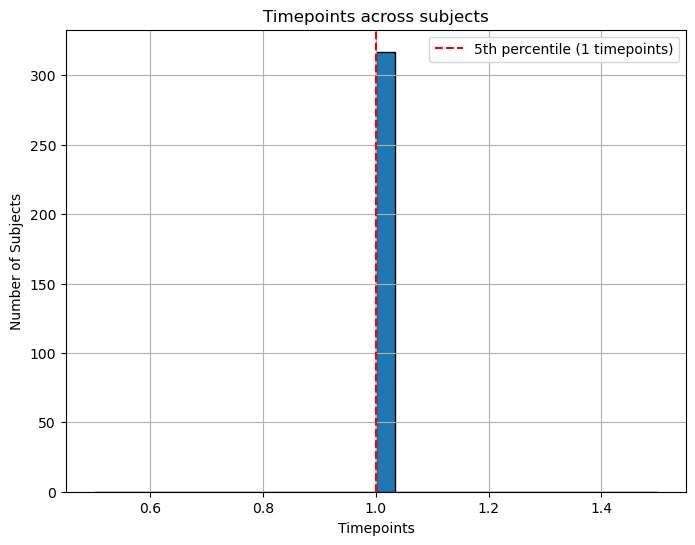

Final usable subjects after filtering: 317


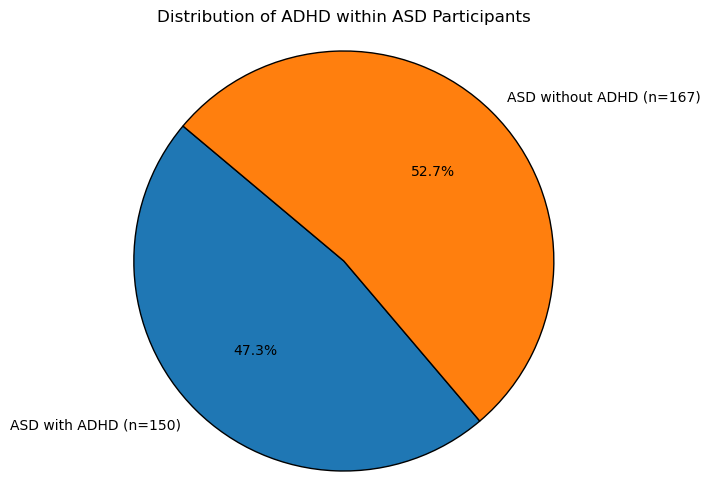

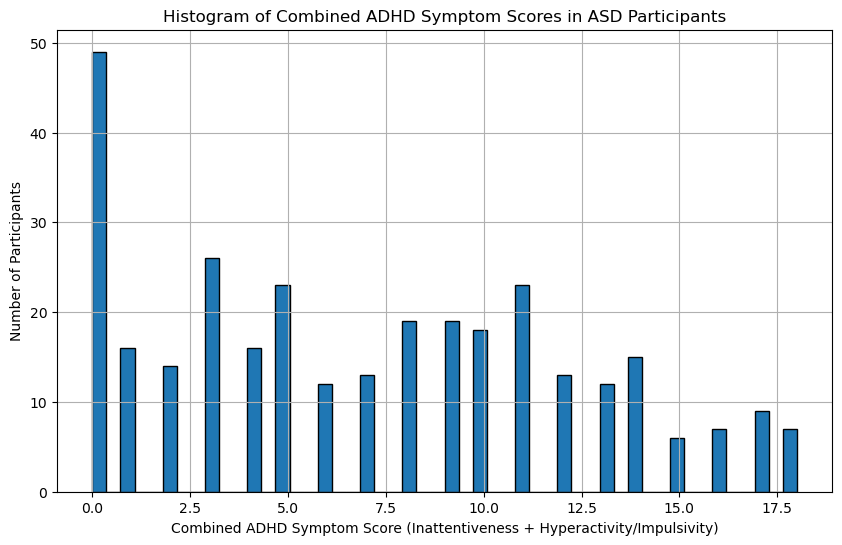

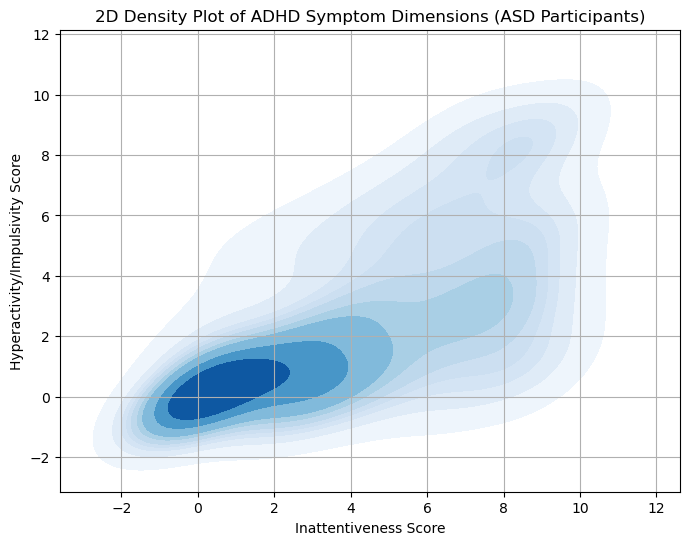

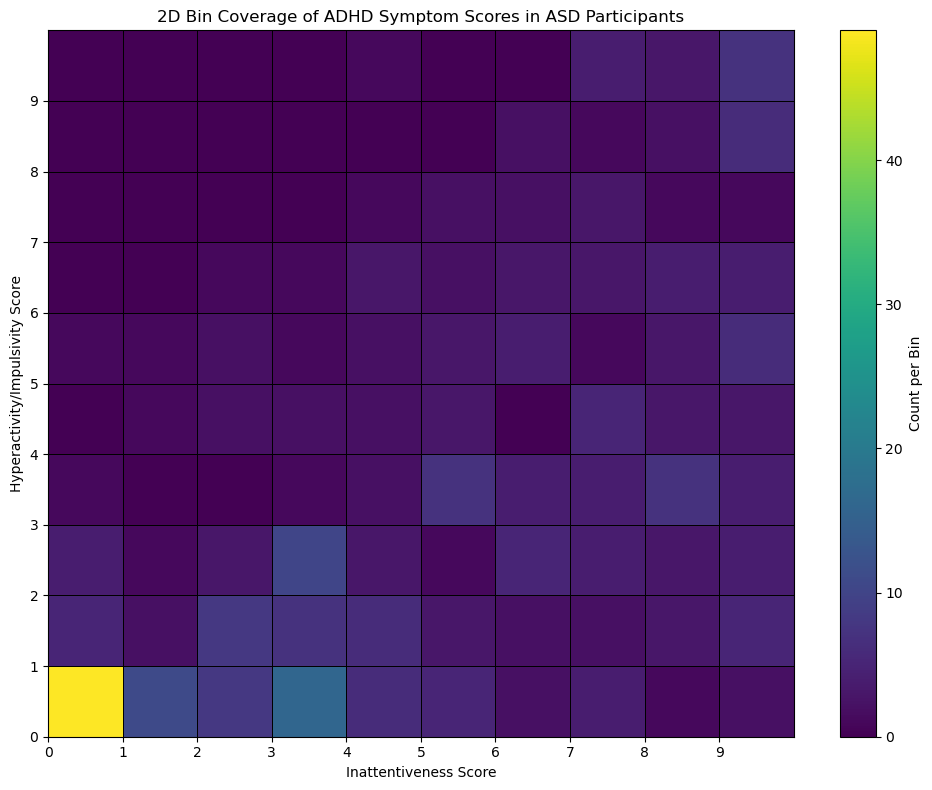

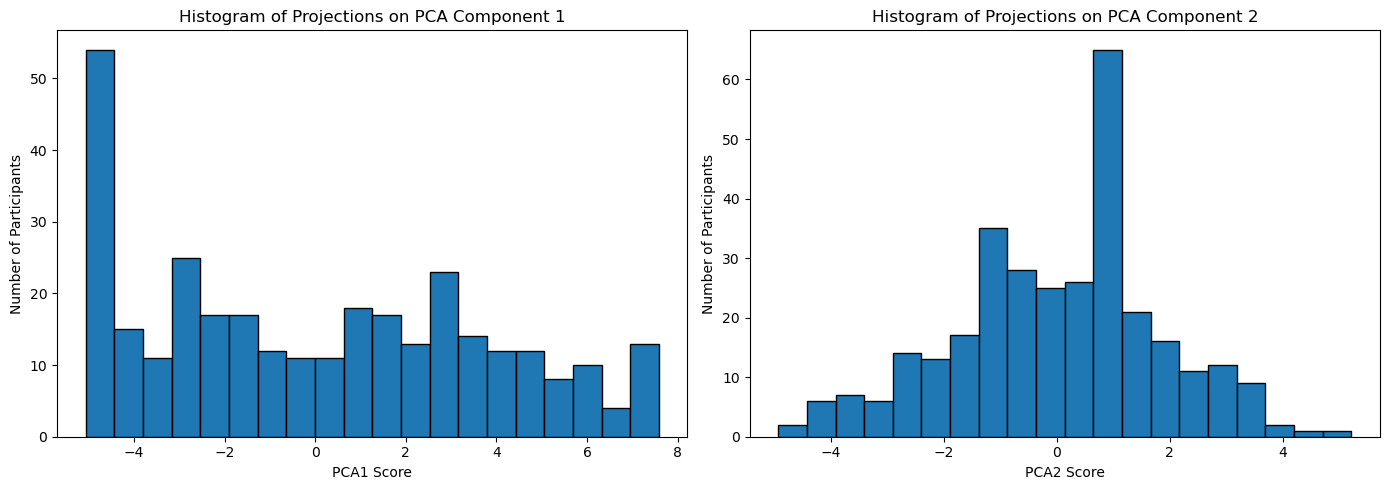

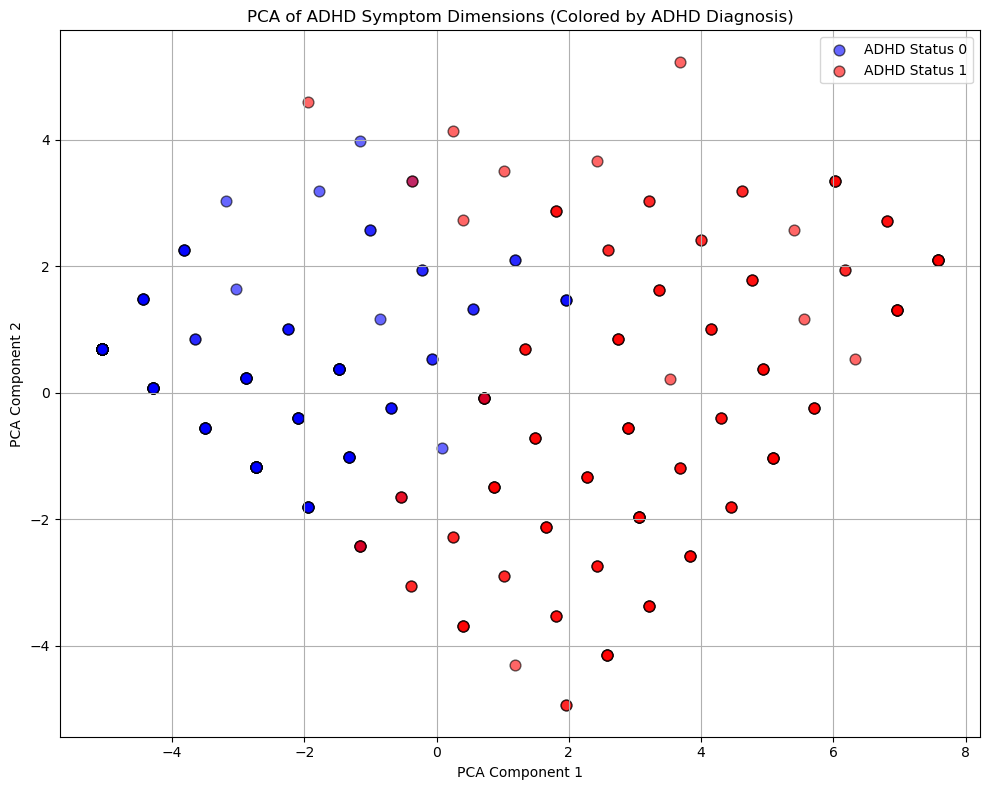

In [9]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from nilearn import image
from sklearn.decomposition import PCA
from nilearn.maskers import NiftiMasker
from joblib import Parallel, delayed


subjects_csv = "/project/3022057.01/LEAP/ASD_ADHD_subjects_gm.csv" 

# 1. ADHD dataset processing
def fix_adhd_scores(row):
    if (row['t1_adhd_inattentiv_parent'] not in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] not in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_parent']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_parent']
    elif (row['t1_adhd_inattentiv_self'] not in [999, 777]) and (row['t1_adhd_hyperimpul_self'] not in [999, 777]) \
         and (row['t1_adhd_inattentiv_parent'] in [999, 777]) and (row['t1_adhd_hyperimpul_parent'] in [999, 777]):
        row['t1_adhd_inattentiv'] = row['t1_adhd_inattentiv_self']
        row['t1_adhd_hyperimpul'] = row['t1_adhd_hyperimpul_self']
    return row

# Load dataset
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
asd_df = df[df['t1_diagnosis'] == 'ASD'].copy()
asd_df = asd_df[~asd_df['t1_adhd_cat_combined'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_ageyrs'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_fsiq'].isin([999, 777])]
asd_df = asd_df[~asd_df['t1_sex'].isin(['999', '777'])]
asd_df = asd_df[~asd_df['t1_site'].isin(['999', '777'])]

# Fix ADHD scores
asd_df['t1_adhd_inattentiv'] = pd.NA
asd_df['t1_adhd_hyperimpul'] = pd.NA
asd_df = asd_df.apply(fix_adhd_scores, axis=1)
asd_df = asd_df.dropna(subset=['t1_adhd_inattentiv', 't1_adhd_hyperimpul'])

# 2. Path building
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'

asd_df['gm_prob'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
asd_df['warp'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
asd_df['subj_t1_mni'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
asd_df['full_brain_mask'] = (
    base_dir + '/' + asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
)

required_cols = ['gm_prob', 'warp', 'subj_t1_mni', 'full_brain_mask']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None


        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        # These live in the same segmentation folder as your gm_prob map
        seg_dir   = os.path.dirname(row['gm_prob'])
        pve0_path = os.path.join(seg_dir, 't1_structural_pve_0.nii.gz')  # CSF
        pve1_path = os.path.join(seg_dir, 't1_structural_pve_1.nii.gz')  # GM
        pve2_path = os.path.join(seg_dir, 't1_structural_pve_2.nii.gz')  # WM

        img0      = nib.load(pve0_path)
        voxel_vol = abs(np.linalg.det(img0.affine[:3, :3]))  # mm³ per voxel
        csf = nib.load(pve0_path).get_fdata()
        gm  = nib.load(pve1_path).get_fdata()
        wm  = nib.load(pve2_path).get_fdata()

        # TIV in mm³
        TIV = np.sum((csf + gm + wm) * voxel_vol)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)
        
        img  = nib.load(out_warped)
        jac = row['warp'].replace('warp.nii.gz', 'jacWA.nii.gz')
        mod = os.path.join(subj_out_dir, "modulated.nii.gz")
        smooth = os.path.join(subj_out_dir, "modulated_smoothed.nii.gz")
        if not os.path.exists(smooth):
            gm = nib.load(out_warped).get_fdata()
            jac = nib.load(jac).get_fdata()
            nib.save(nib.Nifti1Image(gm * jac, img.affine, img.header), mod)
            image.smooth_img(mod, fwhm=8).to_filename(smooth)
            
        masker = NiftiMasker(mask_img=out_binary, standardize=False, dtype="float32")
        mat = masker.fit_transform(smooth)

        return {
            'subject': subj,
            'TIV': TIV,               
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            'data': smooth,
            'mod': mod,
            'prob': out_warped
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
asd_df = asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

timepoint_cutoff = np.percentile([shape[0] for shape in asd_df['flattened_shape']], 5)

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- Drop subjects ---
# New lines after computing cutoffs:
n_timepoints = pd.Series([s[0] for s in asd_df['flattened_shape']], index=asd_df.index)
mask = (n_timepoints >= timepoint_cutoff)
asd_df = asd_df[mask]

print(f"Final usable subjects after filtering: {len(asd_df)}")

# --- Create Labels ---
# Create ADHD status based on t1_adhd_cat_combined
asd_with_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Meets DSM-5 criteria for ADHD'].shape[0]
asd_without_adhd = asd_df[asd_df['t1_adhd_cat_combined'] == 'Does not meet DSM-5 criteria for ADHD'].shape[0]
asd_df['adhd_status'] = asd_df['t1_adhd_cat_combined'].map({'Does not meet DSM-5 criteria for ADHD': 0,'Meets DSM-5 criteria for ADHD': 1})

# ---Save ---
asd_df.to_csv(subjects_csv, index=False)


# Pie Chart
labels = [f'ASD with ADHD (n={asd_with_adhd})', f'ASD without ADHD (n={asd_without_adhd})']
sizes = [asd_with_adhd, asd_without_adhd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of ADHD within ASD Participants')
plt.axis('equal')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(asd_df['t1_adhd_inattentiv'] + asd_df['t1_adhd_hyperimpul'], bins=50, edgecolor='black')
plt.title('Histogram of Combined ADHD Symptom Scores in ASD Participants')
plt.xlabel('Combined ADHD Symptom Score (Inattentiveness + Hyperactivity/Impulsivity)')
plt.ylabel('Number of Participants')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))
sns.kdeplot(
    x=asd_df['t1_adhd_inattentiv'],
    y=asd_df['t1_adhd_hyperimpul'],
    fill=True, 
    cmap="Blues", 
    thresh=0.05
)
plt.xlabel('Inattentiveness Score')
plt.ylabel('Hyperactivity/Impulsivity Score')
plt.title('2D Density Plot of ADHD Symptom Dimensions (ASD Participants)')
plt.grid(True)
plt.show()

# Extract scores
x = asd_df['t1_adhd_inattentiv']
y = asd_df['t1_adhd_hyperimpul']

# Define bin edges exactly (integers only)
x_bins = np.arange(x.min(), x.max() + 2)  # +2 ensures last bin edge includes max score
y_bins = np.arange(y.min(), y.max() + 2)

# 2D histogram
heatmap_data, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

# Set vmax to improve color visibility (e.g., 95th percentile or manual cap)
vmax_clip = np.percentile(heatmap_data, 100)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
c = ax.pcolormesh(xedges, yedges, heatmap_data.T, cmap='viridis', edgecolors='black', linewidth=0.5, vmax=vmax_clip)

# Colorbar
plt.colorbar(c, ax=ax, label='Count per Bin')

# Axis labels and title
ax.set_xlabel('Inattentiveness Score')
ax.set_ylabel('Hyperactivity/Impulsivity Score')
ax.set_title('2D Bin Coverage of ADHD Symptom Scores in ASD Participants')

# Set ticks to integers
ax.set_xticks(np.arange(x.min(), x.max() + 1, 1))
ax.set_yticks(np.arange(y.min(), y.max() + 1, 1))
ax.grid(False)

plt.tight_layout()
plt.show()


# Extract ADHD symptom variables
X = asd_df[['t1_adhd_inattentiv', 't1_adhd_hyperimpul']].dropna().values

# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# Histogram of PC1 and PC2 projections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist( X_pca[:, 0], bins=20, edgecolor='black')
axes[0].set_title('Histogram of Projections on PCA Component 1')
axes[0].set_xlabel('PCA1 Score')
axes[0].set_ylabel('Number of Participants')

axes[1].hist( X_pca[:, 1], bins=20, edgecolor='black')
axes[1].set_title('Histogram of Projections on PCA Component 2')
axes[1].set_xlabel('PCA2 Score')
axes[1].set_ylabel('Number of Participants')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
colors = {0: 'blue', 1: 'red'}

for label in [0, 1]:
    idx = asd_df['adhd_status'] == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'ADHD Status {label}', color=colors[label], alpha=0.6, edgecolor='k', s=60)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of ADHD Symptom Dimensions (Colored by ADHD Diagnosis)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### ASD vs TD Setup

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from nilearn.maskers import NiftiMasker

# Load dataset
td_asd_subjects_csv = "/project/3022057.01/LEAP/final_td_asd_df.csv" 
file_path = '/project_cephfs/3022035.06/LEAP_clinical/LEAP_t1_Core clinical variables_03-09-19-withlabels.xlsx'
df = pd.read_excel(file_path)

# Filter ASD participants
td_asd_df = df.copy()
td_asd_df = td_asd_df[~td_asd_df['t1_ageyrs'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_fsiq'].isin([999, 777])]
td_asd_df = td_asd_df[~td_asd_df['t1_sex'].isin(['999', '777'])]
td_asd_df = td_asd_df[~td_asd_df['t1_site'].isin(['999', '777'])]


# 2. Path building
base_dir = '/project_cephfs/3022035.06/LEAP_wave1'
td_asd_df['data'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D.ica_aroma/nr_wm_csf/highpassfilter/denoised_func_data_nonaggr_res_pp2MNI152.nii.gz'
)
td_asd_df['gm_prob'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/segmentation/t1_structural_prob_1.nii.gz'
)
td_asd_df['warp'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/highres2reference_warp.nii.gz'
)
td_asd_df['subj_t1_mni'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/anatomy/preprocessing/reg2MNI152/reference_brain.nii.gz'
)
td_asd_df['full_brain_mask'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/RS_FMRI_4D_gm_mask2MNI152_bin.nii.gz'
)
td_asd_df['motion_path'] = (
    base_dir + '/' + td_asd_df['subjects'].astype(str) +
    '/BOLD/task006/echocombined/preprocessing/mc/RS_FMRI_4D_mc_rel_mean.rms'
)

required_cols = ['data', 'gm_prob', 'warp', 'subj_t1_mni', 'motion_path', 'full_brain_mask']

output_dir = "/project/3022057.01/LEAP/Masks"
os.makedirs(output_dir, exist_ok=True)

def process_subject_row(row, threshold=0.5):
    try:
        if not all(os.path.exists(row[col]) for col in required_cols):
            return None

        with open(row['motion_path'], 'r') as f:
            motion_value = float(f.read().strip())

        subj = str(row['subjects'])
        subj_out_dir = os.path.join(output_dir, subj)
        os.makedirs(subj_out_dir, exist_ok=True)

        gm_prob = row['gm_prob']
        warp = row['warp']
        ref = row['subj_t1_mni']
        func_file = row['data']

        out_warped = os.path.join(subj_out_dir, "t1_structural_prob_1_in_MNI.nii.gz")
        out_binary = os.path.join(subj_out_dir, "true_gm_mask_in_MNI.nii.gz")

        if not os.path.exists(out_binary):
            print(subj, "saving")
            subprocess.run([
                "applywarp",
                "--in=" + gm_prob,
                "--ref=" + ref,
                "--warp=" + warp,
                "--out=" + out_warped,
                "--interp=trilinear"
            ], check=True)

            img = nib.load(out_warped)
            data = img.get_fdata()
            binary = (data > threshold).astype(np.uint8)
            binary_img = nib.Nifti1Image(binary, img.affine, img.header)
            nib.save(binary_img, out_binary)

        masker = NiftiMasker(mask_img=out_binary, standardize=True, dtype="float32")
        mat = masker.fit_transform(func_file)
        print(subj, mat.shape)

        return {
            'subject': subj,
            'motion': motion_value,
            'mask_path': out_binary,
            'flattened_shape': mat.shape,
            # 'example_volume': masker.inverse_transform(mat[0:1, :])
        }

    except Exception as e:
        print(f"Error processing subject {row['subjects']}: {e}")
        return None

# 4. Parallel processing
n_jobs = 20
results = Parallel(n_jobs=n_jobs)(delayed(process_subject_row)(row) for idx, row in td_asd_df.iterrows())
results = [r for r in results if r is not None]
results_df = pd.DataFrame(results)

results_df['subject'] = results_df['subject'].astype(int)
td_asd_df = td_asd_df.merge(results_df, left_on='subjects', right_on='subject', how='inner')

motion_cutoff = np.percentile(td_asd_df['motion'], 95)
timepoint_cutoff = np.percentile([shape[0] for shape in td_asd_df['flattened_shape']], 5)

# Plot motion
plt.figure(figsize=(8, 6))
plt.hist(td_asd_df['motion'], bins=30, edgecolor='black')
plt.axvline(motion_cutoff, color='r', linestyle='--', label=f'95th percentile ({motion_cutoff:.3f} mm)')
plt.title('Motion values across subjects')
plt.xlabel('Mean Relative Motion (mm)')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# Plot timepoints
plt.figure(figsize=(8, 6))
plt.hist([shape[0] for shape in td_asd_df['flattened_shape']], bins=30, edgecolor='black')
plt.axvline(timepoint_cutoff, color='r', linestyle='--', label=f'5th percentile ({timepoint_cutoff:.0f} timepoints)')
plt.title('Timepoints across subjects')
plt.xlabel('Timepoints')
plt.ylabel('Number of Subjects')
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Drop subjects ---
n_timepoints = pd.Series(
    [s[0] for s in td_asd_df['flattened_shape']],
    index=td_asd_df.index
)
mask = (td_asd_df['motion'] <= motion_cutoff) & (n_timepoints >= timepoint_cutoff)
td_asd_df = td_asd_df[mask]

print(f"Final usable subjects after filtering: {len(td_asd_df)}")

# map diagnosis → binary
td_asd_df['ASD_status'] = td_asd_df['t1_diagnosis'].map({
    'Control': 0,
    'ASD':     1
})

# after filtering:
n_td  = (td_asd_df['ASD_status']==0).sum()
n_asd = (td_asd_df['ASD_status']==1).sum()

td_asd_df.to_csv(td_asd_subjects_csv, index=False)

# Pie Chart
print(f"TD subjects: {n_td}, ASD subjects: {n_asd}")
labels = [f'TD (n={n_td})', f'ASD (n={n_asd})']
sizes = [n_td, n_asd]

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of TD vs. ASD Participants')
plt.axis('equal')
plt.show()

### Set Up and Run Folds

In [24]:
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiMasker
import pandas as pd
import matplotlib.pyplot as plt

def visual_mask(subs ,mask_path, n_qc_subjects):
        # Visualize QC on Random Subjects
        print("\nVisualizing QC on random subjects...")

        mask_img = nib.load(mask_path)
        mask_affine, mask_shape = mask_img.affine, mask_img.shape

        base_brain_dir = "/project_cephfs/3022035.06/LEAP_wave1"
        random_subjects = subs.sample(n=min(n_qc_subjects, len(subs)))
        for idx, subj_row in random_subjects.iterrows():
            subj_id = subj_row['subjects']
            subject_brain_path = os.path.join(base_brain_dir, str(subj_id), "anatomy", "preprocessing", "reg2MNI152", "brain2reference.nii.gz")
            if not os.path.exists(subject_brain_path):
                print(f"Subject {subj_id} brain file not found, skipping...")
                continue

            anat = nib.load(subject_brain_path)
            vbm = nib.load(subj_row['data'])
            for name, img in (("anat", anat), ("vbm", vbm)):
                if img.ndim == 3:
                    if img.shape != mask_shape:
                        print(f"{subj_id} {name} shape {img.shape} ≠ mask {mask_shape}")
                if not np.allclose(img.affine, mask_affine, atol=1e-5):
                    print(f"{subj_id} {name} affine ≠ mask affine")


            subj_brain_img = nib.load(subject_brain_path)

            # Plot the mask over structural
            plotting.plot_roi(mask_img, bg_img=subj_brain_img, title=f"Mask on Subject {subj_id}", draw_cross=False, alpha=0.5)
            plotting.show()

            # Plot first fMRI volume masked
            masker = NiftiMasker(mask_img=mask_path, standardize=False, dtype="float32")
            mat = masker.fit_transform(subj_row['data'])
            reconstructed_func = masker.inverse_transform(mat)

            one_img = nib.Nifti1Image(reconstructed_func.get_fdata(), reconstructed_func.affine, reconstructed_func.header)
            plotting.plot_stat_map(one_img, bg_img=subj_brain_img, threshold=0.0, title=f"VBM: Subject {subj_id}", black_bg=False, dim=0.5)
            plotting.show()

def fold_gm_mask(dataframe, train_idx, test_idx, output_dir, mask_name='group_gm_mask.nii.gz', n_qc_subjects=3):
    os.makedirs(output_dir, exist_ok=True)
    try:
        # Build Group GM Mask
        print("\nBuilding group GM mask from training subjects for fold...")
        
        train_subs = dataframe.iloc[train_idx].reset_index(drop=True)
        test_subs  = dataframe.iloc[test_idx].reset_index(drop=True)

        all_gm_paths = train_subs['prob'].tolist()
        sample_img = nib.load(all_gm_paths[0])
        gm_data = np.stack([nib.load(p).get_fdata() for p in all_gm_paths], axis=0)
        presence = np.mean(gm_data > 0, axis=0)   # fraction of subjects with GM>0
        gm_mask = ((gm_data.max(axis=0) >= 0.1)    # FSL‐VBM style max criterion
                & (presence >= 0.90)           # at least 90% of subs have GM
                ).astype(np.uint8)
        # gm_max  = gm_data.max(axis=0)
        # gm_min  = gm_data.min(axis=0)
        # gm_mask = ((gm_max >= 0.1) & (gm_min > 0)).astype(np.uint8)

        # Save the group GM mask
        mask_path = os.path.join(output_dir, mask_name)
        nib.save(nib.Nifti1Image(gm_mask, sample_img.affine, sample_img.header), mask_path)
        print(f"Saved group GM mask with {int(gm_mask.sum())} voxels at: {mask_path}")
        
        print("Check on Train Subjects")
        visual_mask(train_subs ,mask_path, n_qc_subjects)

        print("Check on Test Subjects")
        visual_mask(test_subs ,mask_path, n_qc_subjects)

    except Exception as e:
        print(f"Error during GM mask building or visualization: {e}")

    print("\nGM Mask creation and QC visualization complete!")
    return mask_path


In [25]:
import sys
sys.path.append('/project/3022057.01/IFA/utils')

import os
import json
import numpy as np
import pickle
import pandas as pd
# from regression import continuous_confounders, categorical_confounders, confounders
import hcp_utils as hcp
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from sklearn.model_selection import StratifiedKFold


settings = {
    "phenotype": [
        "ADHD",      # positive class
        "nonADHD"    # negative class
    ],
    "percentile": 0.15,
    "outputfolder": "/project/3022057.01/ASD_ADHD_gm",
    "n_folds": 4,
    "random_state": 42,
    "n_filters_per_group": 1,
    "nPCA_levels": [
        8
    ],
    "tangent_class": True,
    "tan_class_model": "SVM (C=0.1)",
    "metric": "logeuclid",
    "label": "adhd_status",       # use your ADHD label column
    "a_label": 1,                 # ADHD meets DSM
    "b_label": 0,                 # does not meet
    "deconfound": True,
    "paired": False,
    "cov_log": False,
    "shrinkage": 0.05,
    "age_conf": "t1_ageyrs",
    "sex_conf": "t1_sex",
    "csv": "/project/3022057.01/LEAP/ASD_ADHD_subjects_gm.csv"
}


# Ensure the output folder exists
outputfolder = settings["outputfolder"]
if not os.path.exists(outputfolder):
    os.makedirs(outputfolder)

settings_filepath = os.path.join(outputfolder, 'settings.json')
with open(settings_filepath, 'w') as f:
    json.dump(settings, f, indent=4)

subjects_csv =   settings["csv"]
sub_df = pd.read_csv(subjects_csv)

confounders =  ["age", "sex", "t1_fsiq", "t1_site", "TIV"]
continuous_confounders = ["age", "t1_fsiq", "TIV"]
categorical_confounders = ["sex","t1_site"]
# plt.hist(sub_df["TIV"].div((10**6)).values)
# plt.show()
if settings["deconfound"]:
    age_conf = settings["age_conf"]
    sex_conf = settings["sex_conf"]

    # rename those two columns to generic names
    sub_df = sub_df.rename(columns={age_conf: "age", sex_conf: "sex"})

    con_confounders = sub_df[continuous_confounders]
    cat_confounders = sub_df[categorical_confounders]
    # change variable name here 
    con_confounders.to_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confounders.to_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))



Fold 1

Building group GM mask from training subjects for fold...
Saved group GM mask with 213373 voxels at: /project/3022057.01/ASD_ADHD_gm/fold_0/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


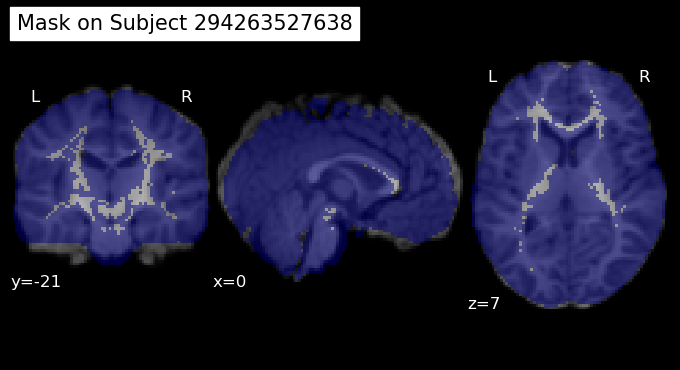

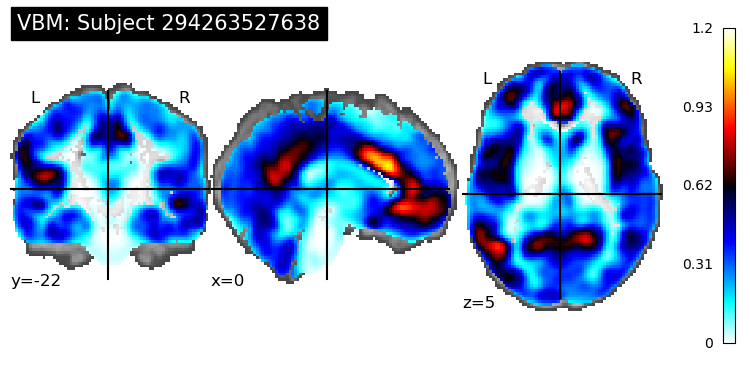

Check on Test Subjects

Visualizing QC on random subjects...


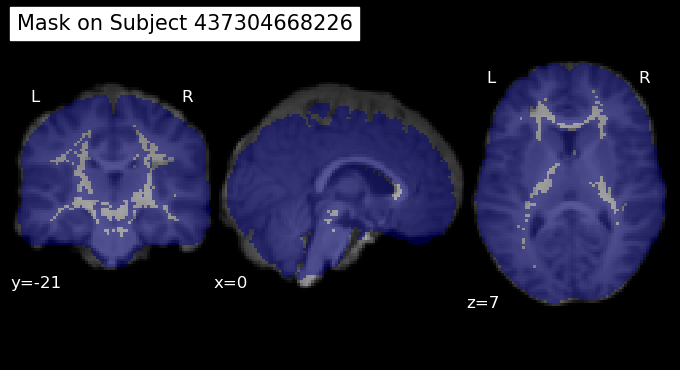

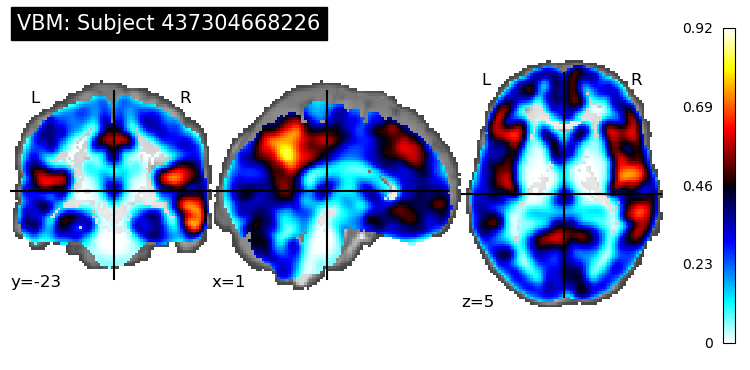


GM Mask creation and QC visualization complete!

Fold 2

Building group GM mask from training subjects for fold...
Saved group GM mask with 214348 voxels at: /project/3022057.01/ASD_ADHD_gm/fold_1/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


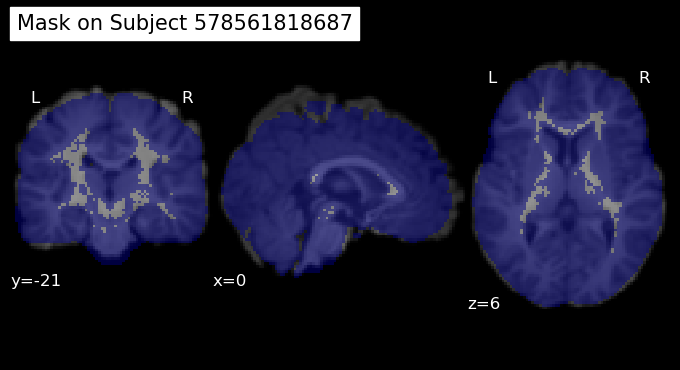

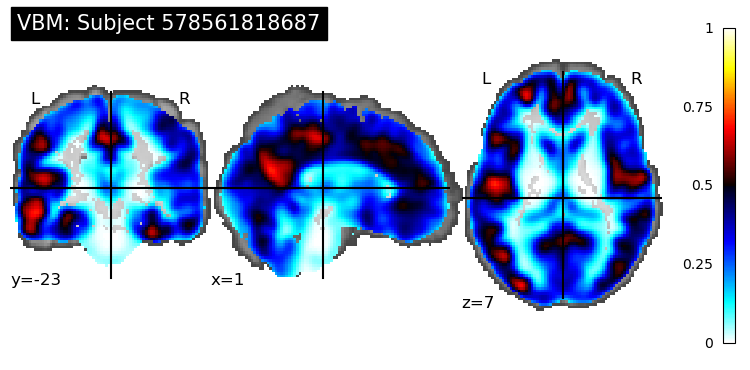

Check on Test Subjects

Visualizing QC on random subjects...


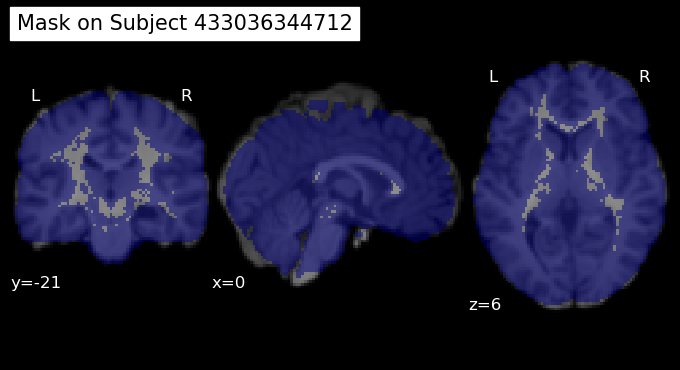

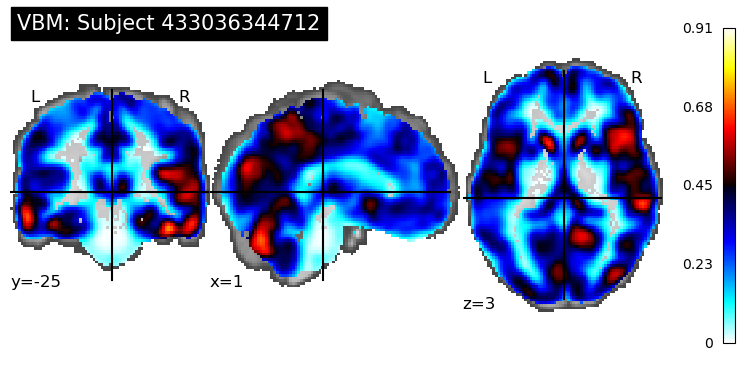


GM Mask creation and QC visualization complete!

Fold 3

Building group GM mask from training subjects for fold...
Saved group GM mask with 217022 voxels at: /project/3022057.01/ASD_ADHD_gm/fold_2/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


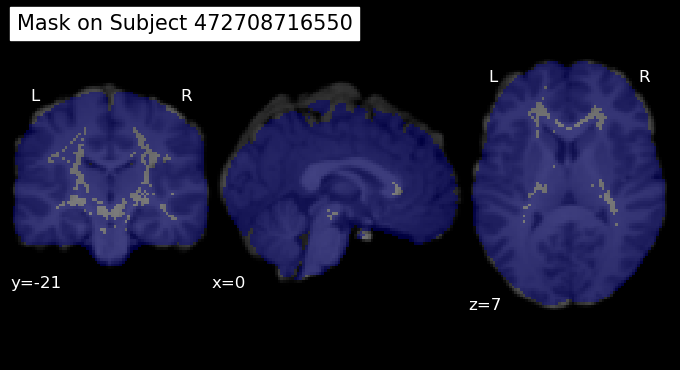

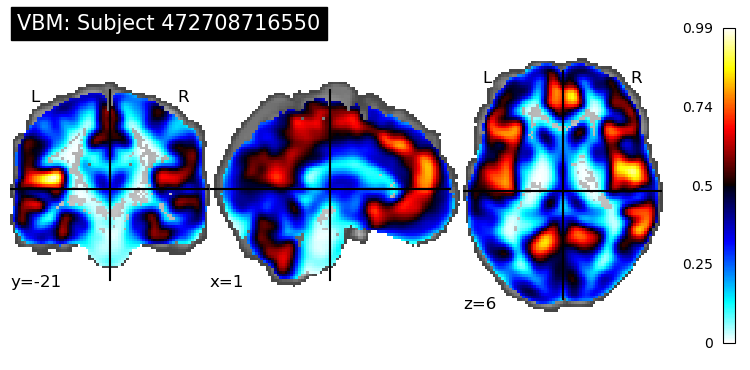

Check on Test Subjects

Visualizing QC on random subjects...


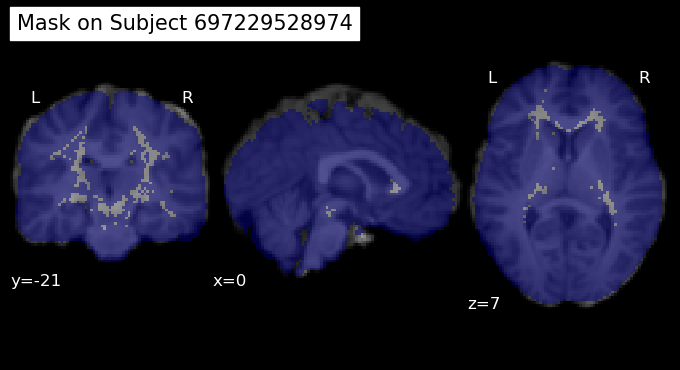

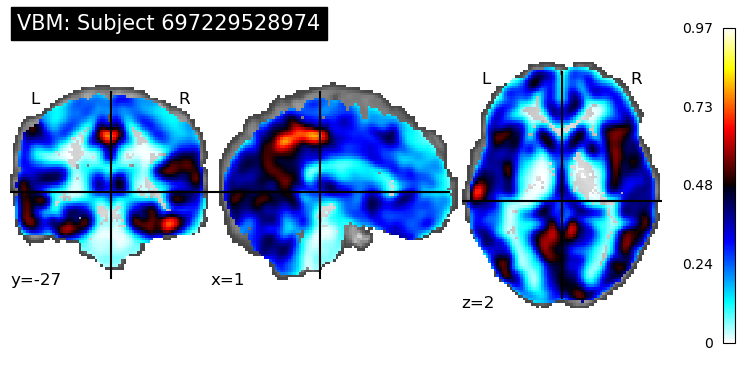


GM Mask creation and QC visualization complete!

Fold 4

Building group GM mask from training subjects for fold...
Saved group GM mask with 216270 voxels at: /project/3022057.01/ASD_ADHD_gm/fold_3/group_gm_mask_fold.nii.gz
Check on Train Subjects

Visualizing QC on random subjects...


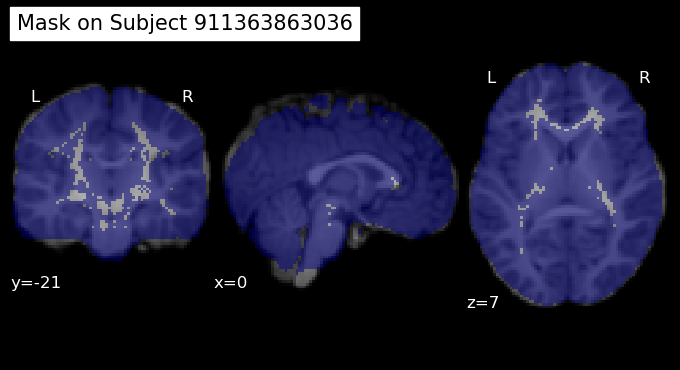

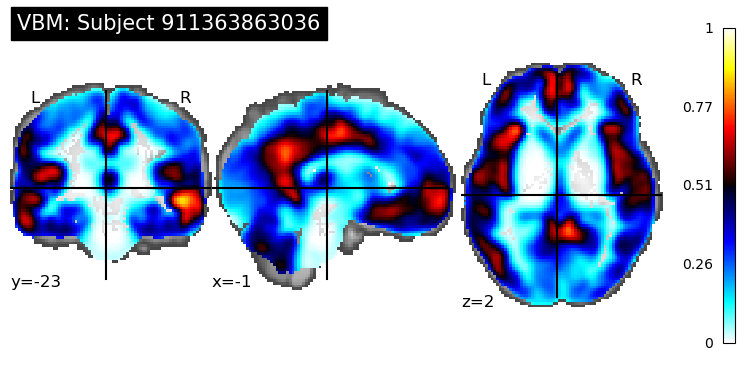

Check on Test Subjects

Visualizing QC on random subjects...


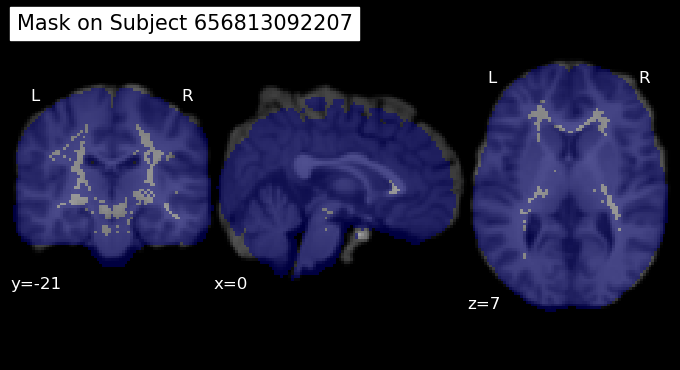

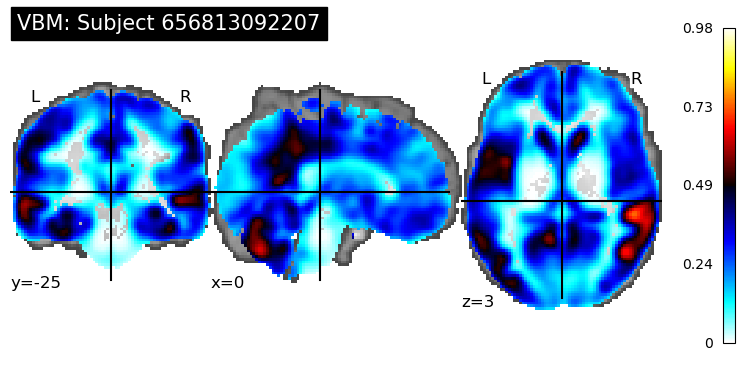


GM Mask creation and QC visualization complete!


In [26]:
import ast
import pickle

n_folds = settings["n_folds"]
random_state = settings["random_state"]

label = settings["label"]
labels = sub_df[label].to_numpy()
np.save(os.path.join(outputfolder,"labels.npy"),labels)

sub_ID = sub_df["subjects"].to_numpy()
np.save(os.path.join(outputfolder,"Sub_ID.npy"),sub_ID)

sub_df['n_timepoints'] = sub_df['flattened_shape'].apply(lambda s: ast.literal_eval(s)[0])
time_points = sub_df["n_timepoints"].to_numpy()
np.save(os.path.join(outputfolder,"time_points.npy"),time_points)

func_paths = sub_df["data"].to_numpy()
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
for fold, (train_idx, test_idx) in enumerate(skf.split(sub_ID, labels)):
    print(f"\nFold {fold+1}")

    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")
    if not os.path.exists(fold_output_dir):
        os.makedirs(fold_output_dir)
    indices_dir = os.path.join(fold_output_dir, "Indices")
    if not os.path.exists(indices_dir):
        os.makedirs(indices_dir)
    np.save(os.path.join(indices_dir, "train_idx.npy"), train_idx)
    np.save(os.path.join(indices_dir, "test_idx.npy"), test_idx)
   
    # Build mask and save into fold folder
    mask_path = fold_gm_mask(dataframe=sub_df, train_idx=train_idx, test_idx=test_idx, output_dir=fold_output_dir, mask_name="group_gm_mask_fold.nii.gz",n_qc_subjects=1)
    
    paths = [(func_path, mask_path) for func_path in func_paths]
    paths = np.array(paths, dtype=object)


    with open(os.path.join(fold_output_dir, "paths.pkl"), "wb") as f:
        pickle.dump(paths, f)


In [ ]:
import os
import subprocess

run_fold_script = "/project/3022057.01/IFA/run_IFA/Partial/run_fold_leap.sh"

# New job per fold
for fold in range(5):
    fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

    command = [
        "sbatch",
        "--job-name", f"fold_{fold}",
        "--output", os.path.join(fold_output_dir, "slurm-%j.out"),
        "--error", os.path.join(fold_output_dir, "slurm-%j.err"),
        run_fold_script,  # Path to `run_fold.sh`
        outputfolder,     # Pass outputfolder as first argument
        str(fold),         # Pass fold as second argument
    ]
    
    # Submit the job
    subprocess.run(command)

In [29]:
import sys
import os
import json
import numpy as np
import argparse
import pickle
from pyriemann.estimation import Covariances
import traceback
from concurrent.futures import ProcessPoolExecutor
import functools
import gc
import pandas as pd
import psutil
import resource
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_basc_multiscale_2015
basc = fetch_atlas_basc_multiscale_2015(resolution=444)
basc_labels = basc.maps

# Add the path to custom modules
sys.path.append('/project/3022057.01/IFA/utils')

# Import necessary modules
from analysis import evaluate, compare
from PCA import PPCA, migp
from filters import orthonormalize_filters, save_brain
from ICA import ICA
from DualRegression import DualRegress
from filters import TSSF, FKT, evaluate_filters
from tangent import tangent_classification
from haufe import partial_filter_dual_regression


# End of save block
from filters import voxelwise_FKT

def save_text_results(text, filepath):
    """Save text results to a file."""
    with open(filepath, "a") as f:  # Using 'a' to append results to the file
        f.write(text + "\n")

def partiallate_subject(sub):
    try:
        func_img, mask_img = sub
        labels_masker = NiftiLabelsMasker(labels_img=basc_labels, mask_img=mask_img, standardize=False,  dtype=np.float32)
        Xp = labels_masker.fit_transform(func_img)
        return Xp
    
    except Exception as e:
        print(f"Error processing subject {sub}: {e}")
        traceback.print_exc()
        raise

def partiallate_subjects(paths, output_dir, n_workers=20):
    try:
        # Create a function that always uses the same vt.
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            partiallated_data_list = list(executor.map(partiallate_subject, paths))


        # Convert the list to a NumPy array.
        data_save_path = os.path.join(output_dir, "partiallated_data.pkl")
        with open(data_save_path, "wb") as f:
            pickle.dump(partiallated_data_list, f)
        print(f"Partiallated data saved to {data_save_path}")
        
        
        return partiallated_data_list
    except Exception as e:
        print(f"Error in parcellation process: {e}")
        traceback.print_exc()
        raise  # Re-raise the error so the process crashes.

def major_recon_discrim(discrim_basis, major_space,output_folder):
    try:
        # Compute reconstruction
        reconstructed = discrim_basis.T @ np.linalg.pinv(major_space) @ major_space
        numerator = np.linalg.norm(discrim_basis.T - reconstructed, 'fro') ** 2
        denominator = np.linalg.norm(discrim_basis.T, 'fro') ** 2
        reconstruction_percentage = (1 - numerator / denominator)
        print("Reconstruction Percentage:", reconstruction_percentage)
        
        # Save the reconstruction percentage
        recon_file = os.path.join(output_folder, "discriminant_reconstruction_percentage_vt.txt")
        with open(recon_file, "w") as f:
            f.write(str(reconstruction_percentage) + "\n")
    except Exception as e:
        print("Failed to compute reconstruction percentage:", e)
        reconstruction_percentage = None

def PPCA_ICA(reducedsubs,basis=None, n_components=None, IFA=True,random_state=42, output_folder=None):
    if not IFA:
        _, basis = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=n_components)

    spatial_maps = ICA(basis, output_dir=output_folder,random_state=random_state)
    spatial_maps = spatial_maps.T
    for i in range(spatial_maps.shape[1]):
        save_brain(spatial_maps[:,i], f"s_map_{i}", output_folder)

    np.save(os.path.join(output_folder, "basis.npy"), basis)
    np.save(os.path.join(output_folder, "spatial_maps.npy"), spatial_maps)

    return spatial_maps

def run_comparisons(results_list, base_output_folder, pairs, alpha=0.05):
    """
    Run pairwise comparisons for a list of evaluation results.
    
    Parameters:
    - results_list: list of evaluation results (e.g., normalized or unnormalized).
    - base_output_folder: base directory where comparison subfolders will be created.
    - pairs: list of tuples (i, j, label_one, label_two) indicating the indices in results_list and their labels.
    """
    if not os.path.exists(base_output_folder):
        os.makedirs(base_output_folder)
        
    for i, j, label_one, label_two in pairs:
        pair_dir = os.path.join(base_output_folder, f"{label_one}_vs_{label_two}")
        if not os.path.exists(pair_dir):
            os.makedirs(pair_dir)
        compare(
            results_list[i], results_list[j],
            label_one=label_one, label_two=label_two,
             alpha=alpha, output_dir=pair_dir
        )

def cpu_mem():
    # Get the soft and hard limits of virtual memory (address space)
    soft, hard = resource.getrlimit(resource.RLIMIT_AS)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")

    # Get the soft and hard limits of the data segment (physical memory usage)
    soft, hard = resource.getrlimit(resource.RLIMIT_DATA)
    print(f"Soft limit: {soft / (1024 ** 3):.2f} GB")
    print(f"Hard limit: {hard / (1024 ** 3):.2f} GB")
   # Display memory information
    print(f"Total Memory: { psutil.virtual_memory().total / (1024**3):.2f} GB")
    print(f"Available Memory: { psutil.virtual_memory().available / (1024**3):.2f} GB")
    print(f"Used Memory: { psutil.virtual_memory().used / (1024**3):.2f} GB")
    print(f"Memory Usage: { psutil.virtual_memory().percent}%")
    

fold = 0

with open(os.path.join(outputfolder, "settings.json"), "r") as f:
    settings = json.load(f)

random_state           = settings["random_state"]
n_filters_per_group    = settings["n_filters_per_group"]
nPCA_levels            = settings["nPCA_levels"]
tangent_class          = settings["tangent_class"]
tan_class_model        = settings["tan_class_model"]
metric                 = settings["metric"]
a_label                = settings["a_label"]
b_label                = settings["b_label"]
deconfound             = settings["deconfound"]
paired                 = settings["paired"]

# Load numpy files
sub_ID = np.load(os.path.join(outputfolder, "Sub_ID.npy"))
labels = np.load(os.path.join(outputfolder, "labels.npy"))
time_points = np.load(os.path.join(outputfolder, "time_points.npy"))

# Load Fold Specific Vairables
fold_output_dir = os.path.join(outputfolder, f"fold_{fold}")

with open(os.path.join(fold_output_dir, "paths.pkl"), "rb") as f:
    paths = pickle.load(f)

summary_file_path = os.path.join(fold_output_dir, "output_summary.txt")
indices_dir = os.path.join(fold_output_dir, "Indices")
train_idx = np.load(os.path.join(indices_dir, "train_idx.npy"))
test_idx = np.load(os.path.join(indices_dir, "test_idx.npy"))
fold_results = os.path.join(fold_output_dir, "Results")
if not os.path.exists(fold_results):
    os.makedirs(fold_results)

# Prepare data for train and test sets
train_labels = labels[train_idx]
train_paths = paths[train_idx]
test_labels = labels[test_idx]

if deconfound:
    con_confs = pd.read_pickle(os.path.join(outputfolder, "con_confounders.pkl"))
    cat_confs = pd.read_pickle(os.path.join(outputfolder, "cat_confounders.pkl"))
    
    train_con_confounders = con_confs.iloc[train_idx]
    test_con_confounders = con_confs.iloc[test_idx]
    train_cat_confounders = cat_confs.iloc[train_idx]
    test_cat_confounders = cat_confs.iloc[test_idx]
else:
    train_con_confounders = None
    test_con_confounders = None
    train_cat_confounders = None
    test_cat_confounders = None

# Save summary of data split
save_text_results(f"Fold {fold + 1}:", summary_file_path)
save_text_results(f"  Train size: {len(train_idx)}", summary_file_path)
save_text_results(f"  Test size: {len(test_idx)}", summary_file_path)
save_text_results(f"  Train labels distribution: {np.bincount(labels[train_idx].astype(int))}", summary_file_path)
save_text_results(f"  Test labels distribution: {np.bincount(labels[test_idx].astype(int))}", summary_file_path)
if paired:
    paired_train = np.array_equal(
        sub_ID[train_idx][train_labels == a_label],
        sub_ID[train_idx][train_labels == b_label]
    )
    paired_test = np.array_equal(
        sub_ID[test_idx][test_labels == a_label],
        sub_ID[test_idx][test_labels == b_label]
    )
    save_text_results(f"  Paired Across Train: {paired_train}", summary_file_path)
    save_text_results(f"  Paired Across Test: {paired_test}", summary_file_path)
    
# # Run MIGP
# migp_dir = os.path.join(fold_output_dir, "MIGP")
# if not os.path.exists(migp_dir):
#     os.makedirs(migp_dir)

# reduced_subs_path = os.path.join(migp_dir, "reducedsubs.npy")
# mA = 2 * time_points[train_idx][train_labels == a_label].max()
# mB = 2 * time_points[train_idx][train_labels == b_label].max()
# if os.path.exists(reduced_subs_path):
#     print(f"Loading existing reducedsubs from {reduced_subs_path}")
#     reducedsubs = np.load(reduced_subs_path)
# else:
#     print("Reducedsubs not found — running MIGP")
#     reducedsubsA = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsA.npy"), reducedsubsA)

#     reducedsubsB = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=1)
#     np.save(os.path.join(migp_dir, "reducedsubsB.npy"), reducedsubsB)

#     reducedsubs = np.concatenate((reducedsubsA, reducedsubsB), axis=0)
#     np.save(reduced_subs_path, reducedsubs)
#     del reducedsubsA, reducedsubsB
#     gc.collect()

nPCA = nPCA_levels[0]
# Directory for resulst for basis spanned by nPCA components + fixed number of filters
nPCA_dir = os.path.join(fold_output_dir, f"nPCA_{nPCA}")
if not os.path.exists(nPCA_dir):
    os.makedirs(nPCA_dir)

# Get Parcellated Filters
filters_dir = os.path.join(nPCA_dir, "Filters")
if not os.path.exists(filters_dir):
    os.makedirs(filters_dir)

# vt_path = os.path.join(filters_dir, "vt.npy")
# if os.path.exists(vt_path):
#     print("Loading existing vt.npy...")
#     vt = np.load(vt_path).astype(np.float32)
# else:
#     print("vt.npy not found, running PPCA...")
#     _, vt = PPCA(reducedsubs.copy(), threshold=0.0, niters=1, n=nPCA)
#     np.save(vt_path, vt)

# # Run the PCA job, now just to get the voxel level filters using GPU
voxel_filters_dir = os.path.join(filters_dir, "Voxel")
if not os.path.exists(voxel_filters_dir):
    os.makedirs(voxel_filters_dir)
        

In [30]:
def memory_profile():
    """Prints current RAM usage, peak RAM usage, and SLURM-allocated memory."""
    # Read /proc/self/status
    # https://hpcf.umbc.edu/general-productivity/checking-memory-usage/
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    # Memory usage
    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6

    # SLURM allocation
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024

    # Print results
    print("[Memory Profile]")
    print(f"  Current RAM used (VmRSS): {ram_current_gb:.2f} GB")
    print(f"  Peak RAM used   (VmPeak): {ram_peak_gb:.2f} GB")
    if slurm_mem_gb is not None:
        print(f"  SLURM Allocated Memory:   {slurm_mem_gb:.2f} GB")
    else:
        print("  SLURM Allocated Memory:   Unknown (not running under SLURM)")

import threading
import time
import os

def read_memory_status():
    """Return current RAM, peak RAM from /proc/self/status."""
    status = {}
    with open("/proc/self/status", "r") as f:
        for line in f:
            parts = line.strip().split(":")
            if len(parts) == 2:
                key, value = parts
                status[key] = value.strip()

    ram_current_gb = int(status.get("VmRSS", "0").split()[0]) / 1e6
    ram_peak_gb = int(status.get("VmPeak", "0").split()[0]) / 1e6
    return ram_current_gb, ram_peak_gb

def get_slurm_memory_allocated():
    """Return memory allocated by SLURM."""
    slurm_mem_gb = None
    if "SLURM_MEM_PER_NODE" in os.environ:
        slurm_mem_gb = int(os.environ["SLURM_MEM_PER_NODE"]) / 1024
    elif "SLURM_MEM_PER_CPU" in os.environ:
        ncpus = int(os.environ.get("SLURM_CPUS_ON_NODE", 1))
        slurm_mem_gb = (int(os.environ["SLURM_MEM_PER_CPU"]) * ncpus) / 1024
    return slurm_mem_gb

def monitor_memory(interval=60, output_file="memory_log.csv", stop_event=None):
    """Monitor memory usage every `interval` seconds, save to CSV."""
    if not os.path.exists(output_file):
        with open(output_file, "w") as f:
            f.write("timestamp,current_ram_gb,peak_ram_gb,slurm_allocated_gb\n")

    slurm_alloc = get_slurm_memory_allocated()

    while not (stop_event and stop_event.is_set()):
        now = time.strftime("%Y-%m-%d %H:%M:%S")
        ram_current, ram_peak = read_memory_status()

        slurm_alloc_value = slurm_alloc if slurm_alloc else 0.0

        with open(output_file, "a") as f:
            f.write(f"{now},{ram_current:.2f},{ram_peak:.2f},{slurm_alloc_value:.2f}\n")
            f.flush()

        print(f"[{now}] Current RAM: {ram_current:.2f} GB | Peak RAM: {ram_peak:.2f} GB")
        time.sleep(interval)



def run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=5):
    try:
        with open(os.path.join(outputfolder, "settings.json"), "r") as f:
            settings = json.load(f)
        

        n_filters_per_group = settings["n_filters_per_group"]
        cov_log = settings["cov_log"]
        shrink = settings["shrinkage"]
        filters_dir = os.path.dirname(voxel_filters_dir)
        vt = np.load(os.path.join(filters_dir, "vt.npy"))
        
        A_path = os.path.join(voxel_filters_dir, "A_partial.npy")
        if os.path.exists(A_path):
            A_partial = np.load(A_path).astype(np.float32) 
            print(f"Loaded existing A_partial from {A_path}")
        else:
            A_partial = migp(train_paths[train_labels == a_label], m=mA, n_jobs=15,batch_size=batch_size,vt=vt)
            A_partial = A_partial.astype(np.float32) 
            np.save(A_path, A_partial)

        B_path = os.path.join(voxel_filters_dir, "B_partial.npy")
        if os.path.exists(B_path):
            B_partial = np.load(B_path).astype(np.float32) 
            print(f"Loaded existing B_partial from {B_path}")
        else:
            B_partial = migp(train_paths[train_labels == b_label], m=mB, n_jobs=15,batch_size=batch_size,vt=vt)
            B_partial = B_partial.astype(np.float32)
            np.save(B_path, B_partial)

        voxelwise_FKT(groupA=A_partial, groupB=B_partial, 
                        n_filters_per_group=n_filters_per_group, 
                        groupA_paths=None, groupB_paths=None, 
                        paths=False,log=cov_log,shrinkage=shrink,
                        cov_method='svd',outputfolder=voxel_filters_dir, save=False, save_img=False)

    except Exception as e:
        print(f"Error in run_pca: {e}", flush=True)
        import traceback
        traceback.print_exc()
        # Exit with non-zero code so SLURM knows the job failed
        sys.exit(1)


# stop_event = threading.Event()
# monitor_thread = threading.Thread(target=monitor_memory, kwargs={"interval": 30, "stop_event": stop_event})
# monitor_thread.start()
# try:
#     # ======= Your real script code below here =======
#     print("Running heavy computation...")

#     run_pca(outputfolder, voxel_filters_dir, train_paths, train_labels, a_label, b_label, mA, mB, batch_size=1)

# finally:
#     # Signal the memory monitor to stop
#     stop_event.set()
#     monitor_thread.join()
#     print("Memory monitoring stopped.")

# memory_profile()
        

# Paths where we'll cache the results
data_save_path = os.path.join(filters_dir, "partiallated_data.pkl")

# Try to load cached results, otherwise compute and save
if os.path.exists(data_save_path):
    # Load previously saved data
    with open(data_save_path, "rb") as f:
        partial_data = pickle.load(f)
    print(f"Loaded partiallated data from {data_save_path}")
else:
    partial_data = partiallate_subjects(paths, output_dir=filters_dir, n_workers=20)

# Then split into train and test using your indices:
partial_train_data = [partial_data[i] for i in train_idx]
partial_test_data  = [partial_data[i] for i in test_idx]

Partiallated data saved to /project/3022057.01/ASD_ADHD_gm/fold_0/nPCA_8/Filters/partiallated_data.pkl


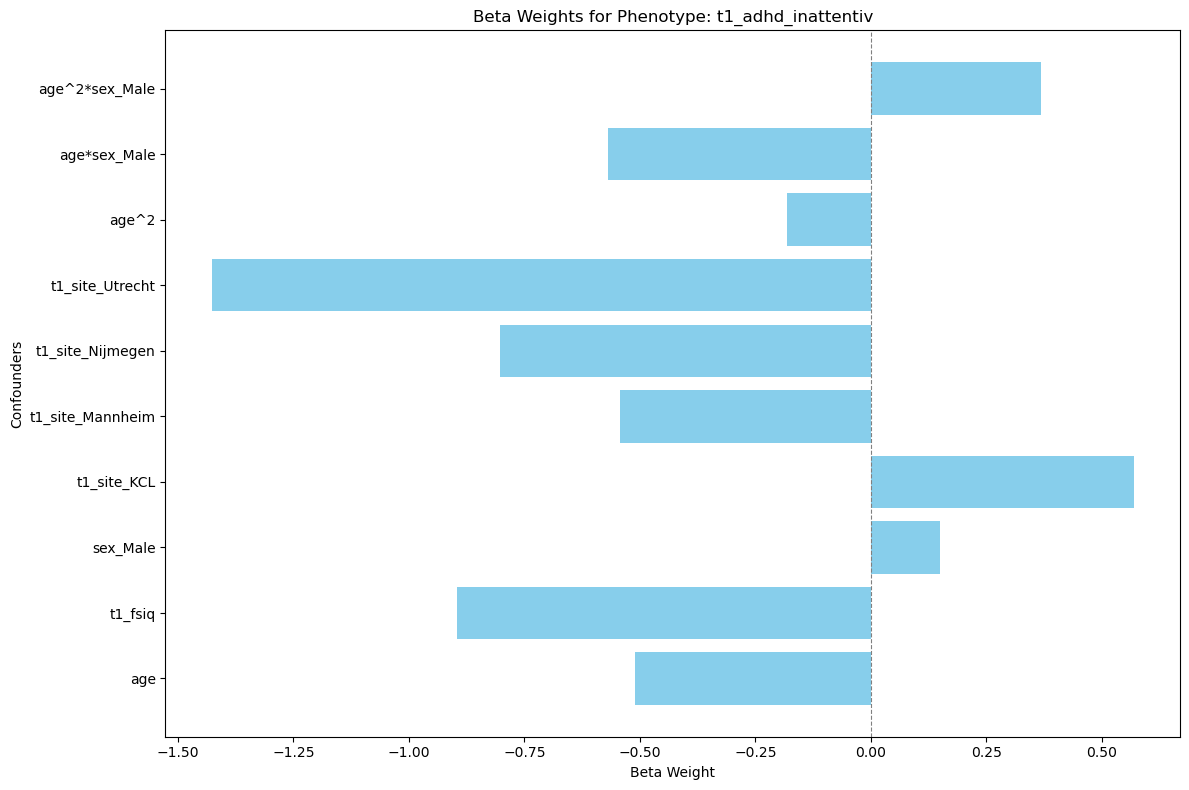

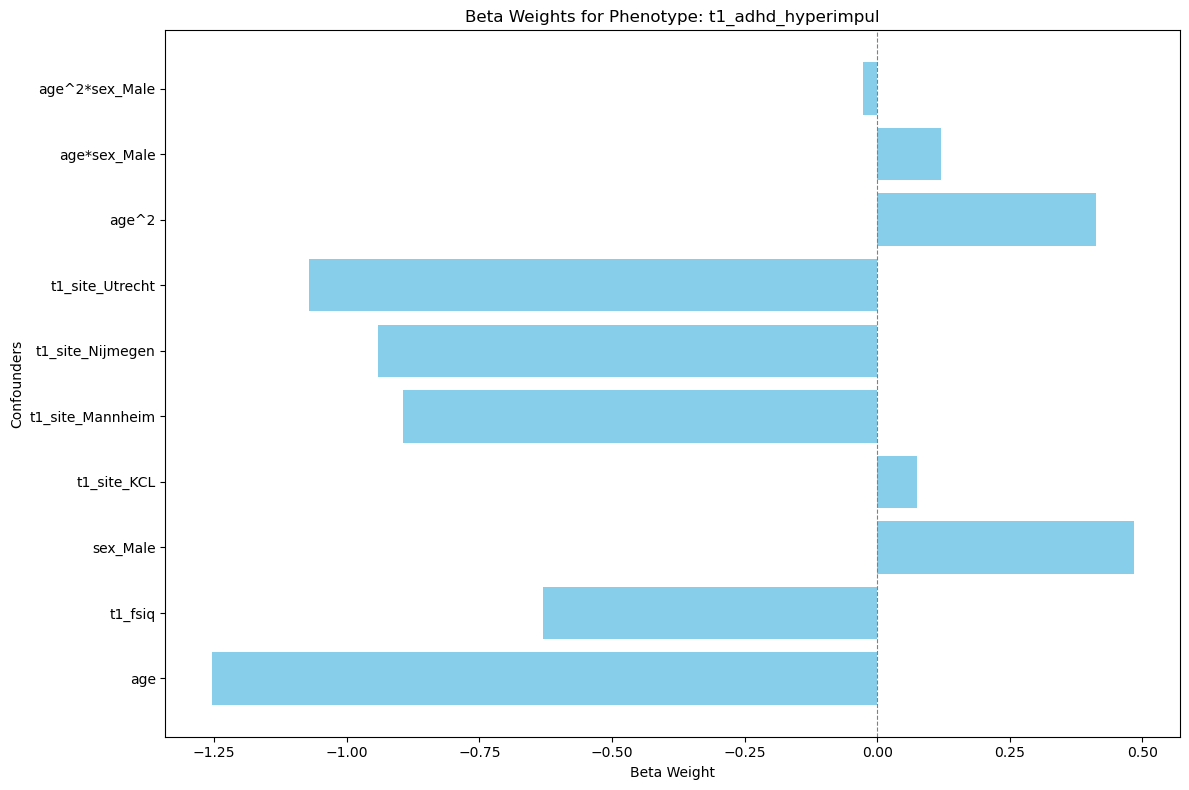

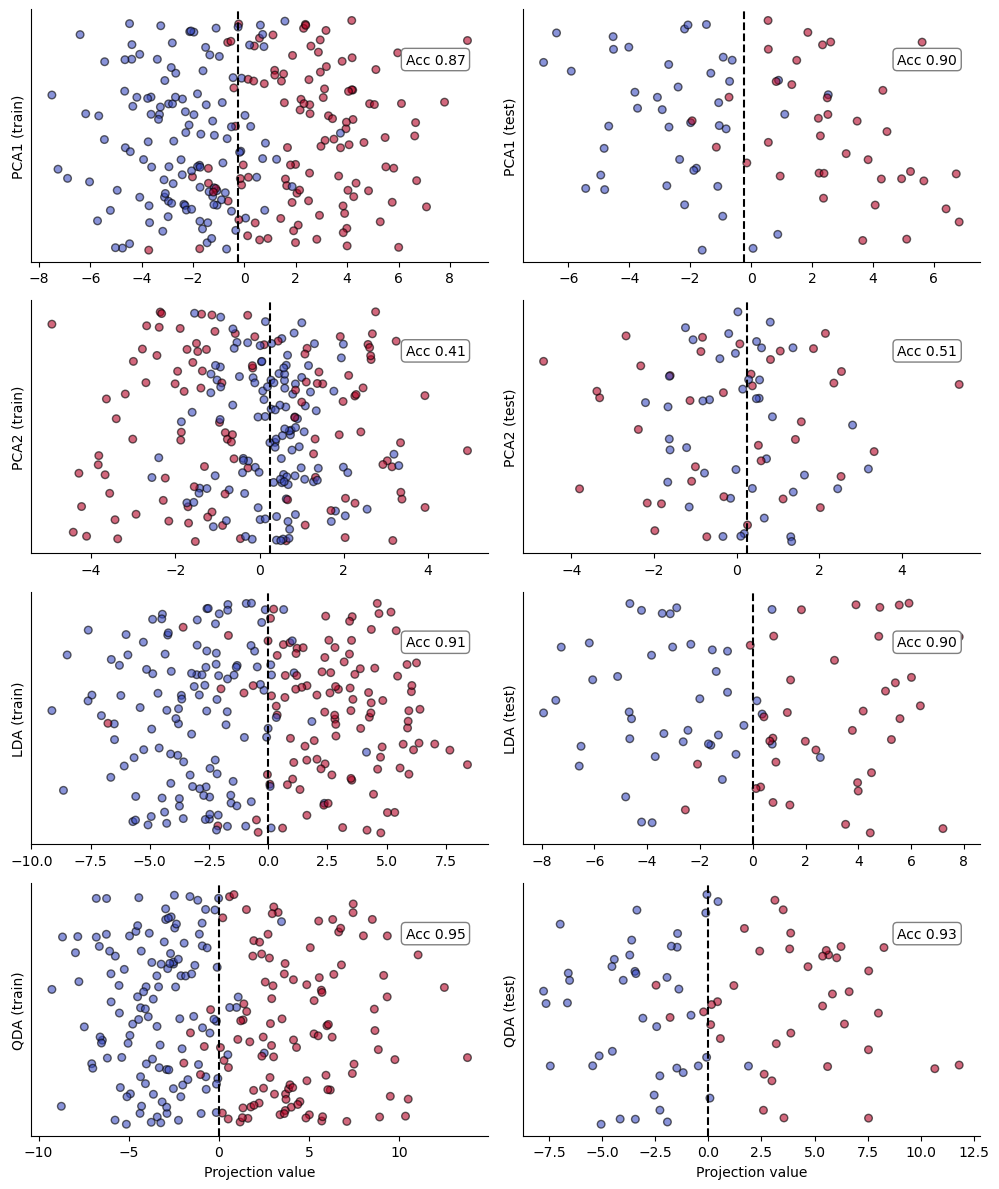

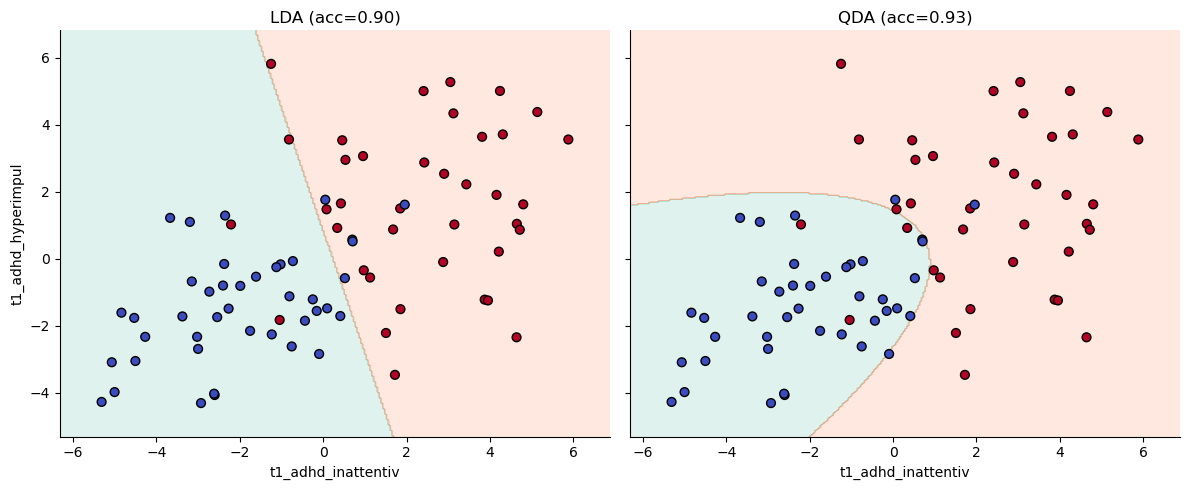

In [52]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import ListedColormap
# make sure your utils folder is on the path
sys.path.append('/project/3022057.01/IFA/utils')
from regression import deconfound

def compare_1d_and_2d_models(df, feature_cols, label_col, train_idx, test_idx,con_train,con_test,cat_train,cat_test, eps=1e-1, tf=0, deconf=False,outputfolder=None):
    if deconf:
        label_con_train = con_train.drop(columns=["TIV"])
        label_con_test  = con_test .drop(columns=["TIV"])
        X_train, X_test = deconfound(df[feature_cols].iloc[train_idx], label_con_train, cat_train, X_test=df[feature_cols].iloc[test_idx], con_confounder_test=label_con_test, cat_confounder_test=cat_test,
            output_path=os.path.join(outputfolder,"betas_fold0")
        )
        X_train = X_train.values.astype(float)
        X_test = X_test.values.astype(float)
    else:
        X = df[feature_cols].values.astype(float)
        X_train, X_test = X[train_idx], X[test_idx]

    y = df[label_col].values.astype(int)
    y_train, y_test = y[train_idx], y[test_idx]
    
    # optional scaling or logit
    if tf == 1:
        scaler = MinMaxScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    elif tf == 2:
        scaler = MinMaxScaler().fit(X_train)
        def logit_transform(arr):
            p = np.clip(scaler.transform(arr), eps, 1-eps)
            return np.log(p/(1-p))
        X_train, X_test = logit_transform(X_train), logit_transform(X_test)


    # fit
    pca = PCA(2).fit(X_train)
    lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
    qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)

    # get 1D scores
    scores = {
        "PCA1": (pca.transform(X_train)[:,0], pca.transform(X_test)[:,0]),
        "PCA2": (pca.transform(X_train)[:,1], pca.transform(X_test)[:,1]),
        "LDA":  (lda.decision_function(X_train),   lda.decision_function(X_test)),
        "QDA":  (qda.decision_function(X_train),   qda.decision_function(X_test)),
    }
    # boundaries from train
    bounds = {k: np.median(train_scores) for k,(train_scores,_) in scores.items()}

    # helper for strip
    def plot_strip(ax, arr, boundary, y, title):
        jit = (np.random.rand(len(arr))-.5)*.02
        ax.scatter(arr, jit, c=y, cmap="coolwarm", edgecolor="k", alpha=0.6, s=30)
        ax.axvline(boundary, color="k", linestyle="--", lw=1.5)
        ax.set_yticks([])
        ax.set_ylabel(title)
        preds = (arr>boundary).astype(int)
        return accuracy_score(y, preds)

    # 2×4 grid
    fig, axes = plt.subplots(4,2, figsize=(10,12), sharex=False)
    for row,(name,(train_s, test_s)) in enumerate(scores.items()):
        if "PCA" not in name:
            b = 0
        else:
            b = bounds[name]
        acc_tr = plot_strip(axes[row,0], train_s, b, y_train, name+" (train)")
        acc_te = plot_strip(axes[row,1], test_s,  b, y_test,  name+" (test)")
        axes[row,0].text(.95,.8,f"Acc {acc_tr:.2f}", transform=axes[row,0].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        axes[row,1].text(.95,.8,f"Acc {acc_te:.2f}", transform=axes[row,1].transAxes,
                         ha="right",va="center",bbox=dict(boxstyle="round",fc="w",ec=".5"))
        for c in (0,1):
            axes[row,c].spines['top'].set_visible(False)
            axes[row,c].spines['right'].set_visible(False)
            axes[row,c].grid(False)
    axes[-1,0].set_xlabel("Projection value")
    axes[-1,1].set_xlabel("Projection value")
    plt.tight_layout()
    plt.show()

    # 2D decision on TEST only
    acc_lda = lda.score(X_test,y_test)
    acc_qda = qda.score(X_test,y_test)
    xx,yy = np.meshgrid(
        np.linspace(X_test[:,0].min()-1,X_test[:,0].max()+1,300),
        np.linspace(X_test[:,1].min()-1,X_test[:,1].max()+1,300))
    grid = np.c_[xx.ravel(),yy.ravel()]
    Z_lda = lda.predict(grid).reshape(xx.shape)
    Z_qda = qda.predict(grid).reshape(xx.shape)
    cmap0 = ListedColormap(['#66c2a5','#fc8d62'])

    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5),sharex=True,sharey=True)
    ax1.contourf(xx,yy,Z_lda,alpha=.2,cmap=cmap0)
    ax1.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
    ax1.set_title(f"LDA (acc={acc_lda:.2f})"); ax1.set_xlabel(feature_cols[0]); ax1.set_ylabel(feature_cols[1])
    ax2.contourf(xx,yy,Z_qda,alpha=.2,cmap=cmap0)
    ax2.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolor='k',s=40)
    ax2.set_title(f"QDA (acc={acc_qda:.2f})"); ax2.set_xlabel(feature_cols[0])
    for ax in (ax1,ax2):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(False)
    plt.tight_layout()
    plt.show()

    train_scores = qda.decision_function(X_train)
    test_scores  = qda.decision_function(X_test)

    train_df = pd.DataFrame(
        {'decision_score': train_scores},
        index=train_idx
    )
    test_df = pd.DataFrame(
        {'decision_score': test_scores},
        index=test_idx
    )

    return train_df, test_df

targets_train, targets_test = compare_1d_and_2d_models(
    df=sub_df,
    feature_cols=["t1_adhd_inattentiv","t1_adhd_hyperimpul"],
    label_col="adhd_status",
    train_idx=train_idx,
    test_idx=test_idx,
    tf = 0,
    deconf=settings["deconfound"],
    con_train=train_con_confounders, con_test=test_con_confounders, cat_train=train_cat_confounders, cat_test=test_cat_confounders,
    outputfolder=settings["outputfolder"]
)

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# classifcation
partial_train_data = np.array(partial_train_data).squeeze()
partial_test_data = np.array(partial_test_data).squeeze()

X_train, X_test = deconfound(partial_train_data, train_con_confounders, train_cat_confounders, X_test=partial_test_data, con_confounder_test=test_con_confounders, cat_confounder_test=test_cat_confounders)


# 1) Build an SVM pipeline
svm_clf = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',      # radial‐basis function
        C=1,             # regularization strength
        gamma='scale',     # 1 / (n_features * X.var())
        probability=True,  # enable predict_proba for ROC AUC
        random_state=42
    )
)

# 2) Fit on train
svm_clf.fit(X_train, train_labels)

# 3) Predict on test
y_pred  = svm_clf.predict(X_test)
y_proba = svm_clf.predict_proba(X_test)[:, 1]

# 4) Evaluate
acc    = accuracy_score(test_labels, y_pred)
auc    = roc_auc_score(test_labels, y_proba)
cm     = confusion_matrix(test_labels, y_pred)
report = classification_report(test_labels, y_pred)

print(f"Test accuracy : {acc:.3f}")
print(f"Test ROC AUC  : {auc:.3f}")
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", report)

# y_scaler = StandardScaler()
# y_train = y_scaler.fit_transform(targets_train.values)
# y_test  = y_scaler.transform(targets_test.values)

# y_train_df = sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[train_idx]
# y_test_df = sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[test_idx]
targets_train = sub_df[["t1_adhd_inattentiv"]].iloc[train_idx]
targets_test = sub_df[["t1_adhd_inattentiv"]].iloc[test_idx]
label_con_train = train_con_confounders.drop(columns=["TIV"])
label_con_test  = test_con_confounders .drop(columns=["TIV"])
y_train, y_test = deconfound(targets_train, label_con_train, train_cat_confounders, X_test=targets_test, con_confounder_test=label_con_test, cat_confounder_test=test_cat_confounders,
    output_path=os.path.join(outputfolder,"betas_fold0")
)

y_train = np.asarray(y_train)
y_test  = np.asarray(y_test)
print(y_train.shape, y_test.shape)
cols = targets_train.columns.tolist()
for i, col in enumerate(cols):
    plt.figure(figsize=(8, 4))
    
    # histogram
    sns.histplot(targets_train[col], kde=True, stat="density", element="step",
                label="Train", color="C0", alpha=0.5, bins=20)
    sns.histplot(targets_test[col],  kde=True, stat="density", element="step",
                label="Test",  color="C1", alpha=0.5, bins=20)
    plt.title(f"Distribution of “{col}” in Train vs. Test")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    
    # histogram
    sns.histplot(y_train[:, i], kde=True, stat="density", element="step",
                label="Train", color="C0", alpha=0.5, bins=20)
    sns.histplot(y_test[:, i],  kde=True, stat="density", element="step",
                label="Test",  color="C1", alpha=0.5, bins=20)
    
    plt.title(f"Distribution of “{col}” in Train vs. Test Deconfounded and Transformed")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

reg_model = ElasticNet(alpha=10,l1_ratio=0.001)
# reg_model = Ridge(alpha=10)
# fit & predict
reg_model.fit(X_train, y_train[:, i])
y_pred_i = reg_model.predict(X_test)
r2_i = r2_score(y_test[:, i], y_pred_i)
print(f"{col} → Test R² = {r2_i:.3f}")

# scatter true vs pred
plt.figure(figsize=(5,5))
plt.scatter(y_test[:, i], y_pred_i, alpha=0.7)
mn, mx = y_test[:, i].min(), y_test[:, i].max()
plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
plt.xlabel(f"True {col}")
plt.ylabel(f"Pred {col}")
plt.title(f"{col} (R²={r2_i:.2f})")
plt.tight_layout()
plt.show()

# residual diagnostics
res = y_test[:, i] - y_pred_i

# 1) Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(y_pred_i, res, alpha=0.7)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.title(f"{col} Residuals vs Fitted (R²={r2_i:.2f})")
plt.tight_layout()
plt.show()

# 2) QQ‐plot
sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
plt.title(f"{col} QQ Plot")
plt.tight_layout()
plt.show()

# 3) Histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(res, bins=25, edgecolor='k')
plt.title(f"{col} Residuals Histogram")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()



: 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from pyriemann.estimation import Covariances
from filters import haufe_transform
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
import scipy.stats as stats
import sys
from importlib import reload
from pyriemann.utils.tangentspace import untangent_space, unupper
from scipy.linalg import eigh
import seaborn as sns

# make sure your utils folder is on the path
sys.path.append('/project/3022057.01/IFA/utils')
from regression import deconfound

# initial imports
import classification
import filters

# whenever you edit either file, just reload them:
reload(classification)
reload(filters)

# then pull in the names you need
from classification import clf_dict, linear_classifier
from filters        import TSSF, evaluate_filters, feature_generation
from tangent        import tangent_transform

def regression_tangent_pipeline(train_data, test_data,covs_train,covs_test, settings,con_train=None,con_test=None,cat_train=None,cat_test=None,
                                 y_train_df=None, y_test_df=None, haufe = False,raw_target=True):
    deconf = settings.get('deconfound', True)
    metric = settings.get('metric', "logeuclid")
    outputfolder = settings.get("outputfolder")

    X_train_pre, X_test_pre, _ = tangent_transform(covs_train, covs_test, metric=metric)
    if deconf:
        X_train_pre, X_test_pre = deconfound(X_train_pre, con_train, cat_train, X_test=X_test_pre, con_confounder_test=con_test, cat_confounder_test=cat_test)
    
    if raw_target:
        if deconf:
            label_con_train = con_train.drop(columns=["motion"])
            label_con_test  = con_test .drop(columns=["motion"])
            y_train, y_test = deconfound(y_train_df, label_con_train, cat_train, X_test=y_test_df, con_confounder_test=label_con_test, cat_confounder_test=cat_test,
                output_path=os.path.join(outputfolder,"betas_fold0")
            )
        else:
            # simple standardization of each target column
            y_scaler = StandardScaler()
            # note: scaler expects 2D array, so pass .values
            y_train = y_scaler.fit_transform(y_train_df.values)
            y_test  = y_scaler.transform(y_test_df.values)
    else:
        # y_train = y_train_df.values
        # y_test = y_test_df.values
        y_scaler = StandardScaler()
        # note: scaler expects 2D array, so pass .values
        y_train = y_scaler.fit_transform(y_train_df.values)
        y_test  = y_scaler.transform(y_test_df.values)
        
    # force into np.ndarray
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)
    print(y_train.shape, y_test.shape)
    cols = y_train_df.columns.tolist()
    for i, col in enumerate(cols):
        plt.figure(figsize=(8, 4))
        
        # histogram
        sns.histplot(y_train_df[col], kde=True, stat="density", element="step",
                    label="Train", color="C0", alpha=0.5, bins=20)
        sns.histplot(y_test_df[col],  kde=True, stat="density", element="step",
                    label="Test",  color="C1", alpha=0.5, bins=20)
        
        plt.title(f"Distribution of “{col}” in Train vs. Test")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 4))
        
        # histogram
        sns.histplot(y_train[:, i], kde=True, stat="density", element="step",
                    label="Train", color="C0", alpha=0.5, bins=20)
        sns.histplot(y_test[:, i],  kde=True, stat="density", element="step",
                    label="Test",  color="C1", alpha=0.5, bins=20)
        
        plt.title(f"Distribution of “{col}” in Train vs. Test Deconfounded and Transformed")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()


    # n_targets = y_train.shape[1]
    # model_pre = PLSRegression(n_components=1)
    model_pre = Ridge(alpha=10)
    # model_pre = ElasticNet(alpha=1,l1_ratio=0.01)
    model_pre.fit(X_train_pre, y_train)
    y_pred_pre = model_pre.predict(X_test_pre)
     # average R² across targets
    r2_avg_pre = r2_score(y_test, y_pred_pre, multioutput="uniform_average")
    print(f"Tangent Model: Avg R² over targets = {r2_avg_pre:.3f}")
    # If y_pred_pre is 1D, convert it to 2D with shape (n_samples, 1)
    if y_pred_pre.ndim == 1:
        y_pred_pre = y_pred_pre[:, np.newaxis]

    if y_test.ndim == 1:
        y_test = y_test[:, np.newaxis]

    # plot true vs pred for each target
    for i, col in enumerate(y_train_df.columns):
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:,i], y_pred_pre[:,i], alpha=0.7)
        plt.plot([y_test[:,i].min(), y_test[:,i].max()],
                 [y_test[:,i].min(), y_test[:,i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"Tangent {col} (R²={r2_score(y_test[:,i], y_pred_pre[:,i]):.2f})")
        plt.tight_layout()
        plt.show()

    # 2) Plot the loadings (weights) for that component
    # coef = np.atleast_2d(model_pre.x_weights_)
    coef = np.atleast_2d(model_pre.coef_)    # shape = (n_features,)
    if coef.shape[1] != X_train_pre.shape[1]:
        coef = coef.T
    if haufe:
        coef = haufe_transform(X_train_pre, coef.T, method="basic")
    print(coef.shape)
    # Here the matrix remains in the tangent space so the eigenvalues are in terms of the riemannian metric
    boundary_matrix = unupper(coef)[0,:,:]
    print(boundary_matrix.shape)
    eigs, spatial_filters  = eigh(boundary_matrix)
    riem_eig = eigs**2

    plt.scatter(range(0,riem_eig.shape[0]),riem_eig)
    plt.title("Riemannian Distance Supported by Spatial Filter")
    plt.xlabel("Max Eigenvector for Group B to Max Eigenvector for Group A")
    # plt.ylabel(r"$|log(\lambda)|$")
    plt.ylabel(r"$\log(\lambda)^2$")
    plt.show()

    filters_set = spatial_filters[:,[0,-1]]
    X_train, X_test = feature_generation(train_data, test_data, filters_set, method='log-cov', metric=metric, cov="oas")


    # n_targets = y_train.shape[1]
    model = PLSRegression(n_components=1)
    model.fit(X_train, y_train)
    T_test, U_test = model.transform(X_test, y_test)  
    print(T_test.shape, U_test.shape)
    # R² on the latent dimension
    r2_latent = r2_score(U_test[:,0], T_test[:,0])
    print(f"Latent R² = {r2_latent:.3f}")
    
    # 1) Scatter X-latent vs. Y-latent
    plt.figure(figsize=(6,6))
    plt.scatter(T_test[:,0], U_test[:,0], alpha=0.7)
    plt.xlabel("X latent score (T)")
    plt.ylabel("Y latent score (U)")
    plt.title("PLS Latent Space (1 component)")
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8,4))
    plt.bar(np.arange(X_train.shape[1]), model.x_weights_[:,0])
    plt.xlabel("Feature index")
    plt.ylabel("X-loading")
    plt.title("PLS X-weights for Latent Component 1")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.bar(np.arange(y_train.shape[1]), model.y_weights_[:,0])
    plt.xticks(np.arange(y_train.shape[1]), y_train_df.columns, rotation=45, ha="right")
    plt.ylabel("Y-loading")
    plt.title("PLS Y-weights for Latent Component 1")
    plt.tight_layout()
    plt.show()


    y_pred = model.predict(X_test)

     # average R² across targets
    r2_avg = r2_score(y_test, y_pred, multioutput="uniform_average")
    print(f"Avg R² over targets = {r2_avg:.3f}")

    # per‐target R²
    for i, col in enumerate(y_train_df.columns):
        r2i = r2_score(y_test[:,i], y_pred[:,i])
        print(f"  {col}  R² = {r2i:.3f}")
    
    # plot true vs pred for each target
    for i, col in enumerate(y_train_df.columns):
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:,i], y_pred[:,i], alpha=0.7)
        plt.plot([y_test[:,i].min(), y_test[:,i].max()],
                 [y_test[:,i].min(), y_test[:,i].max()],
                 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{col} (R²={r2_score(y_test[:,i], y_pred[:,i]):.2f})")
        plt.tight_layout()
        plt.show()

    def check_resids(true, pred, label):
        res = true - pred
        r2  = r2_score(true, pred)

        # Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(pred, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{label} Residuals vs Fitted (R²={r2:.2f})")
        plt.tight_layout()
        plt.show()

        # QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{label} QQ Plot")
        plt.tight_layout()
        plt.show()

        # Histogram
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{label} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

    # check each original target
    for i, col in enumerate(y_train_df.columns):
        check_resids(y_test[:,i], y_pred[:,i], col)

    # and also the latent
    check_resids(U_test[:,0], T_test[:,0], "Latent")


    print("\n=== Per-phenotype ElasticNet on tangent features ===")
    for i, col in enumerate(y_train_df.columns):
        # ----- Swap these two lines to use SVR instead -----
        # reg = ElasticNet(alpha=1.0, l1_ratio=0.01, max_iter=10000)
        # reg = SVR(C=0.1, epsilon=0.1)
        reg = Ridge(alpha=1.0)
        # --------------------------------------------------

        # fit & predict
        reg.fit(X_train, y_train[:, i])
        y_pred_i = reg.predict(X_test)
        r2_i = r2_score(y_test[:, i], y_pred_i)
        print(f"{col} → Test R² = {r2_i:.3f}")

        # scatter true vs pred
        plt.figure(figsize=(5,5))
        plt.scatter(y_test[:, i], y_pred_i, alpha=0.7)
        mn, mx = y_test[:, i].min(), y_test[:, i].max()
        plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
        plt.xlabel(f"True {col}")
        plt.ylabel(f"Pred {col}")
        plt.title(f"{col} (R²={r2_i:.2f})")
        plt.tight_layout()
        plt.show()

        # residual diagnostics
        res = y_test[:, i] - y_pred_i

        # 1) Residuals vs Fitted
        plt.figure(figsize=(6,4))
        plt.scatter(y_pred_i, res, alpha=0.7)
        plt.axhline(0, color='k', linestyle='--')
        plt.xlabel("Fitted")
        plt.ylabel("Residual")
        plt.title(f"{col} Residuals vs Fitted (R²={r2_i:.2f})")
        plt.tight_layout()
        plt.show()

        # 2) QQ‐plot
        sm.graphics.qqplot(res, dist=stats.norm, fit=True, line="45")
        plt.title(f"{col} QQ Plot")
        plt.tight_layout()
        plt.show()

        # 3) Histogram of residuals
        plt.figure(figsize=(6,4))
        plt.hist(res, bins=25, edgecolor='k')
        plt.title(f"{col} Residuals Histogram")
        plt.xlabel("Residual")
        plt.tight_layout()
        plt.show()

# t1_adhd_inattentiv
# t1_adhd_hyperimpul
# ["t1_adhd_inattentiv","t1_adhd_hyperimpul"]
# ["t1_vabsdscoresc_dss", "t1_vabsdscoresd_dss", "t1_vabsdscoress_dss", "t1_vabsabcabc_standard"]
# sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[train_idx]
# sub_df[["t1_adhd_inattentiv","t1_adhd_hyperimpul"]].iloc[test_idx]
regression_tangent_pipeline(partial_train_data, partial_test_data, partial_train_covs, partial_test_covs, settings,
                                con_train=train_con_confounders, con_test=test_con_confounders, cat_train=train_cat_confounders, cat_test=test_cat_confounders,
                                y_train_df=targets_train, 
                                y_test_df=targets_test, 
                                haufe = False,raw_target=False)


In [ ]:
import sys
from importlib import reload

# make sure your utils folder is on the path
sys.path.append('/project/3022057.01/IFA/utils')

# initial imports
import classification
import filters

# whenever you edit either file, just reload them:
reload(classification)
reload(filters)

# then pull in the names you need
from classification import clf_dict, linear_classifier
from filters        import TSSF, evaluate_filters


In [ ]:
import re

metric = "logeuclid"
deconf= settings["deconfound"]
# n_filters_per_group = 1
# tan_class_model = 'Logistic Regression (l2 C=10)'
def sanitize(name):
    # lowercase, replace non-alphanumeric with underscore
    return re.sub(r'[^0-9a-zA-Z]+', '_', name).strip('_').lower()

for tan_class_model in clf_dict.keys():
    model_slug = sanitize(tan_class_model)
    for z in [0]:
            for n_filters_per_group in [1]:
                for hp in [False, True]:
                    print(f"Running {tan_class_model} | z={z} | filters={n_filters_per_group} | Haufe {hp}")

                    # 1) build a run-specific directory
                    run_dir = os.path.join(filters_dir, model_slug, f"z{z}", f"filt{n_filters_per_group}")
                    os.makedirs(run_dir, exist_ok=True)
        

                    # Run tangent classification for measuring separability in parcellated space
                    tangent_class_metrics = tangent_classification(partial_train_covs, train_labels, partial_test_covs, test_labels, 
                                        clf_str=tan_class_model, z_score=z, metric=metric, deconf=deconf, 
                                        con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                        con_confounder_test=test_con_confounders, cat_confounder_test=test_cat_confounders)

                    # Save those tangent classification results to overall fold results directory
                    with open(os.path.join(filters_dir, "tangent_class_metrics.pkl"), "wb") as f:
                        pickle.dump(tangent_class_metrics, f)   
                    save_text_results("Parcellated Tangent Classification " + str(tangent_class_metrics), summary_file_path)


                    # Directory for all things related to the parecllated filters
                    parcellated_filters_dir = os.path.join(filters_dir, "Parcellated")
                    if not os.path.exists(parcellated_filters_dir):
                        os.makedirs(parcellated_filters_dir)

                    if tangent_class:
                        # eigs, filters_all, W, C = TSSF(X_train_bal, y_train_bal, 
                        #                                     clf_str=tan_class_model, metric=metric, deconf=deconf, 
                        #                                     con_confounder_train=train_con_bal, cat_confounder_train=train_cat_bal, 
                        #                                     z_score=z, haufe=hp, visualize=True, output_dir=parcellated_filters_dir)
                        eigs, filters_all, W, C = TSSF(partial_train_covs, train_labels, 
                                            clf_str=tan_class_model, metric=metric, deconf=deconf, 
                                            con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                            z_score=z, haufe=hp, visualize=True, output_dir=run_dir)
                    else:
                        eigs, filters_all = FKT(X_train_bal, y_train_bal, a_label, b_label,
                                                metric=metric, deconf=deconf, 
                                                con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                                visualize=True, output_dir=parcellated_filters_dir)

                    # if TSSF was used then the lower label is the negative class and corresponds to eigenvalues < 1
                    if a_label < b_label and tangent_class:
                        filtersB = filters_all[:, -n_filters_per_group:]
                        filtersA = filters_all[:, :n_filters_per_group]
                    else: 
                        filtersA = filters_all[:, -n_filters_per_group:]
                        filtersB = filters_all[:, :n_filters_per_group]

                    filters_parcellated = np.concatenate((filtersB, filtersA), axis=1)

                    # np.save(os.path.join(parcellated_filters_dir, "filtersA.npy"), filtersA)
                    # np.save(os.path.join(parcellated_filters_dir, "filtersB.npy"), filtersB)
                    # np.save(os.path.join(parcellated_filters_dir, "filters_parcellated.npy"), filters_parcellated)
                    # for i in range(filters_parcellated.shape[1]):
                    #     save_brain(hcp.unparcellate(filters_parcellated[:,i],hcp.mmp), f"parcellated_filter_{i}", parcellated_filters_dir)

                    # Evaluate filters and save those results to overall fold results directory
                    logvar_stats, logcov_stats = evaluate_filters(partial_train_data, train_labels, partial_test_data, test_labels, 
                                                                            filters_parcellated, metric=metric, deconf=deconf, 
                                                                            con_confounder_train=train_con_confounders, cat_confounder_train=train_cat_confounders, 
                                                                            con_confounder_test=test_con_confounders, cat_confounder_test=test_cat_confounders,output_dir=run_dir)


                    def plot_accuracy_scatter(stats_dict, title):
                        models = list(stats_dict.keys())
                        accuracies = [stats_dict[m]['accuracy'] for m in models]
                        x = range(len(models))

                        plt.figure(figsize=(10, 5))
                        plt.scatter(x, accuracies, s=100)  # you can adjust size with `s`
                        plt.axhline(0.6, color='red', linestyle='--', linewidth=2, label='60% threshold')

                        plt.xticks(x, models, rotation=45, ha='right')
                        plt.ylabel('Accuracy')
                        plt.title(title)
                        plt.legend()
                        plt.tight_layout()
                        plt.show()

                    # After you compute logvar_stats and logcov_stats:
                    plot_accuracy_scatter(logvar_stats, "Log-Var Filter Feature Classification")
                    plot_accuracy_scatter(logcov_stats, "Log-Cov Filter Feature Classification")


                    with open(os.path.join(filters_dir, "logvar_stats.pkl"), "wb") as f:
                            pickle.dump(logvar_stats, f)     
                    with open(os.path.join(filters_dir, "logcov_stats.pkl"), "wb") as f:
                            pickle.dump(logcov_stats, f)      
                    save_text_results(f"Running {tan_class_model} | z={z} | filters={n_filters_per_group}", summary_file_path)
                    save_text_results("Log Var Filter Feature Classification " + str(logvar_stats), summary_file_path)
                    save_text_results("Log Cov Filter Feature Classification " + str(logcov_stats), summary_file_path)

In [ ]:
# Then call
filtersA_transform = partial_filter_dual_regression(filtersA, partial_train_data_a, train_paths[idx_a_label], vt, workers=15)
filtersB_transform = partial_filter_dual_regression(filtersB, partial_train_data_b, train_paths[idx_b_label], vt, workers=15)


np.save(os.path.join(parcellated_filters_dir, "A_filters_haufe.npy"), filtersA_transform)
np.save(os.path.join(parcellated_filters_dir, "B_filters_haufe.npy"), filtersB_transform)
parcelvoxel_filters = orthonormalize_filters(filtersA_transform, filtersB_transform)
np.save(os.path.join(parcellated_filters_dir, "filters.npy"), parcelvoxel_filters)
# for i in range(parcelvoxel_filters.shape[1]):
#     save_brain(parcelvoxel_filters[:,i], f"parcelvoxel_filters{i}", parcellated_filters_dir)